<a href="https://colab.research.google.com/github/gitbidec6/Machine-Learning-Works/blob/main/Power_prediction_new.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Import the neccessary libraries and dependances to perform the regressional problem to predict power.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_excel('/content/EnergyDenisty.xlsx')
df.head().style.set_properties(**{'background-color': 'OliveDrab',
                           'color': 'white',
                           'border-color': 'darkblack'})

,SSA (m2/g),Average PSD (nm),Total pore volume (cm3/g),Intensity ratio,C (%),O (%),Potential window (V),Energy density (Wh/kg)
0,714,4.840000,0.860000,1.490000,82.720000,14.530000,1.000000,7.920000
1,2087,3.630000,1.894000,1.090000,95.160000,4.840000,2.500000,25.66
2,2401.300000,2.310000,1.430000,0.670000,96.660000,2.700000,1.000000,10.830000
3,939.870000,4.340000,0.450000,1.100000,82.800000,9.830000,1.800000,18.300000
4,3272.500000,1.360000,1.110000,1.050000,97.060000,2.870000,1.000000,14.5


In [ ]:
df.describe().style.background_gradient(cmap='rainbow')

,Average PSD (nm),Intensity ratio,C (%),O (%),Potential window (V)
count,250.000000,250.000000,250.000000,250.000000,250.000000
mean,2.771801,1.156032,84.443956,11.655540,1.373600
std,1.710884,0.512906,9.497310,6.770457,0.513515
min,0.208000,0.490000,6.040000,0.260000,0.600000
25%,1.992500,0.940250,81.325000,6.800000,1.000000
50%,2.390000,1.010000,86.080000,10.340000,1.200000
75%,3.057500,1.129500,90.247500,14.845000,1.600000
max,14.960000,4.300000,98.820000,42.290000,4.000000


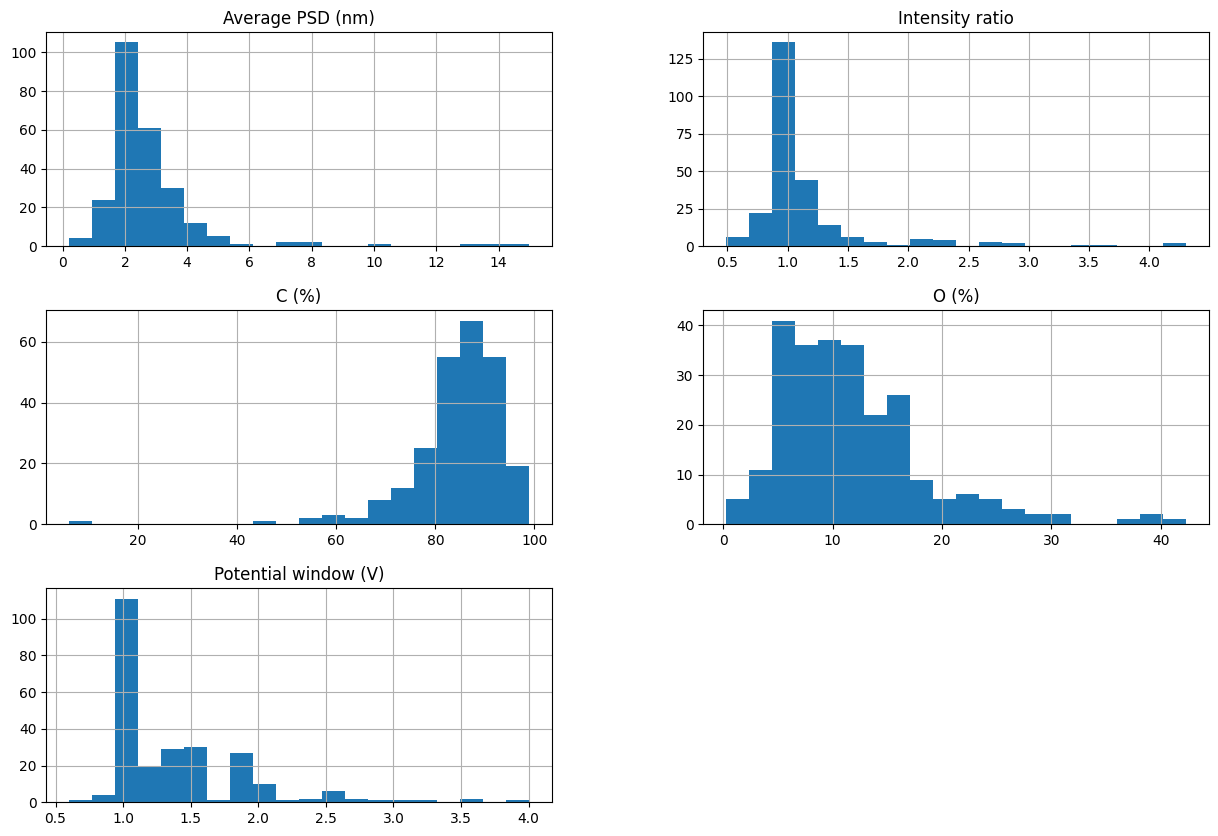

In [ ]:
df.hist(bins=20, figsize=(15, 10))
plt.show()

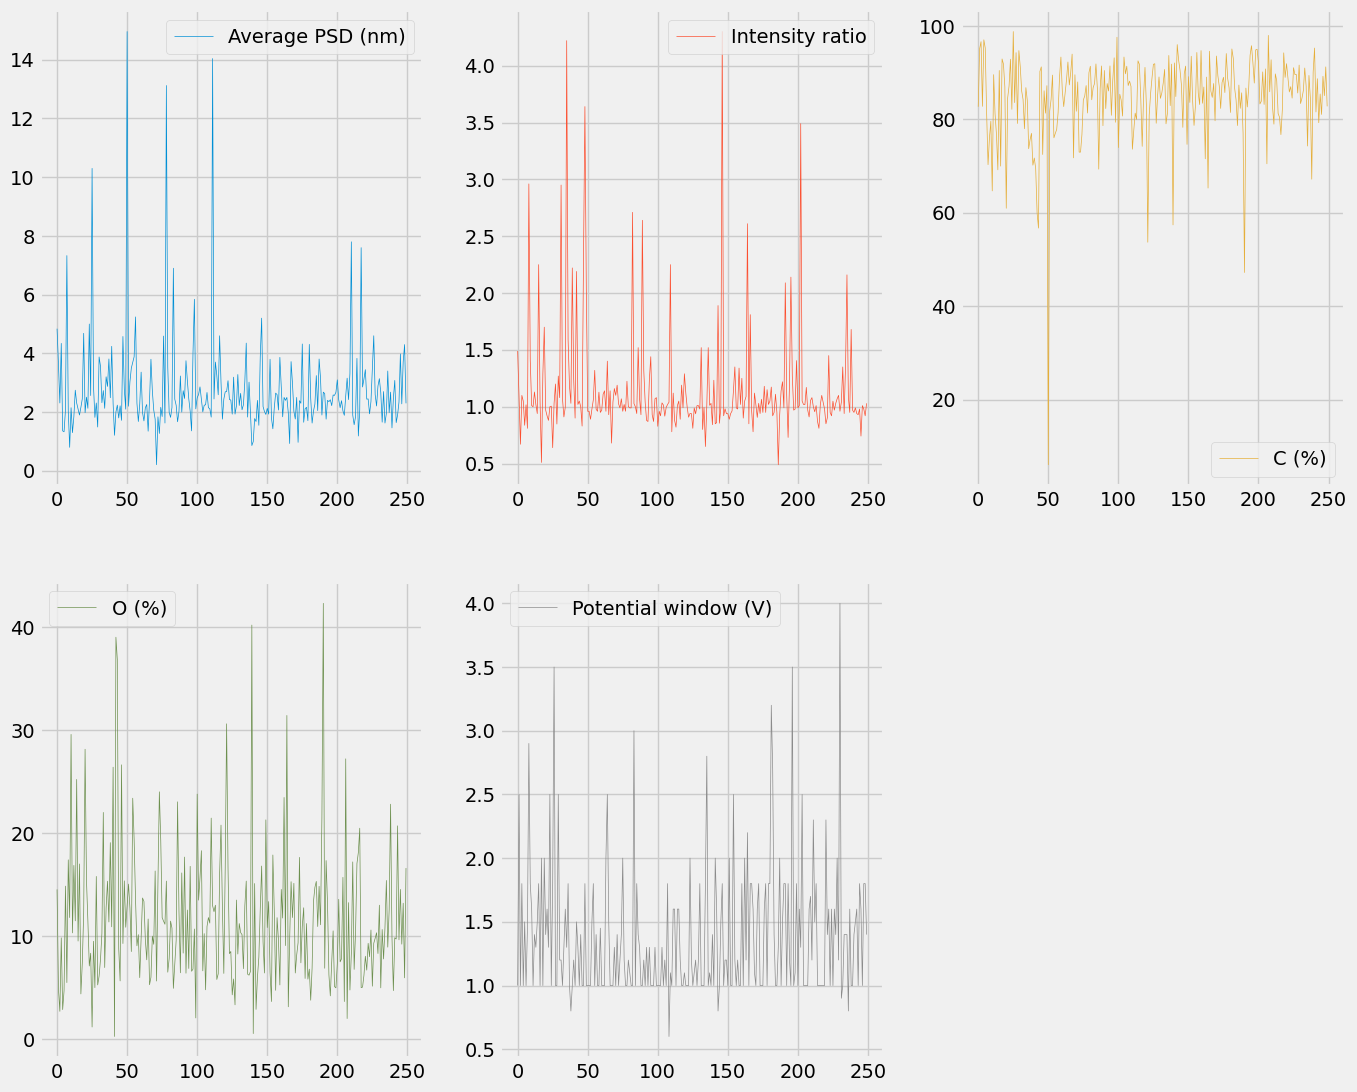

In [ ]:
plt.style.use('fivethirtyeight')
df2 = df.copy('Deep')
# df2 = df2.set_index('Time') # Removed this line

#Facet plots
df2.plot(subplots=True,
         linewidth=0.5,
         layout=(3,3),
         figsize=(15, 20),
         sharex=False,
         sharey=False)
plt.show()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   SSA (m2/g)                 250 non-null    object 
 1   Average PSD (nm)           250 non-null    float64
 2   Total pore volume (cm3/g)  250 non-null    object 
 3   Intensity ratio            250 non-null    float64
 4   C (%)                      250 non-null    float64
 5   O (%)                      250 non-null    float64
 6   Potential window (V)       250 non-null    float64
 7   Energy density (Wh/kg)     250 non-null    object 
dtypes: float64(5), object(3)
memory usage: 15.8+ KB


In [ ]:
df.describe()

,Average PSD (nm),Intensity ratio,C (%),O (%),Potential window (V)
count,250.000000,250.000000,250.000000,250.000000,250.000000
mean,2.771801,1.156032,84.443956,11.655540,1.373600
std,1.710884,0.512906,9.497310,6.770457,0.513515
min,0.208000,0.490000,6.040000,0.260000,0.600000
25%,1.992500,0.940250,81.325000,6.800000,1.000000
50%,2.390000,1.010000,86.080000,10.340000,1.200000
75%,3.057500,1.129500,90.247500,14.845000,1.600000
max,14.960000,4.300000,98.820000,42.290000,4.000000


## Key observation
The dataset comprises 54,160 observations for six features: Ambient Temp (0C), Panel Temp (0C), Irradiance (W/m2), Voltage (v), Current (A), and Power (W). The mean values for these features are generally moderate, but significant variability is observed, particularly in Current (A) and Power (W), as indicated by high standard deviations. The minimum values of zero across all features suggest periods with no recorded activity or measurements. Notably, the large discrepancy between the mean and median in features like Current (A) indicates potential skewness in the data distribution. The presence of extreme values, as seen in the maximum recorded readings, further underscores the data's broad range and variability.

In [ ]:
# check a for empty data entries. It was observed no entry is empty
df.isnull().sum()

,0
SSA (m2/g),0
Average PSD (nm),0
Total pore volume (cm3/g),0
Intensity ratio,0
C (%),0
O (%),0
Potential window (V),0
Energy density (Wh/kg),0


## Data inference

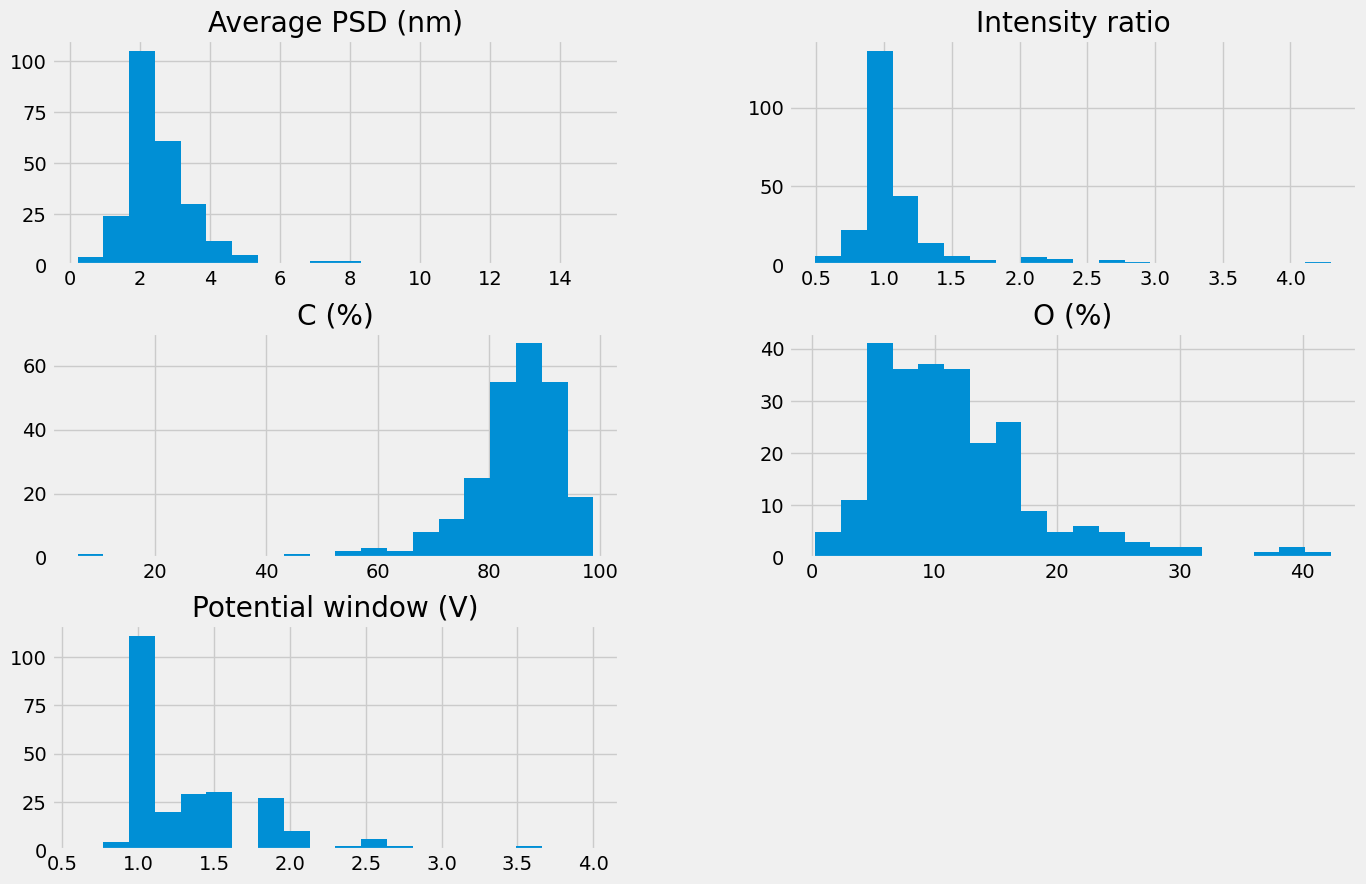

In [ ]:
# The following indicate each feature classs distribution as shown below. Example Irradiance (W/m2) distribution indicate a skew distribution of
# the data class value where most of the value are above 400.
df.hist(bins=20, figsize=(15, 10))
plt.show()

### Data scalling

In many machine learning and statistical modeling applications, standard scaling is a crucial preprocessing step that enhances model performance and interpretation. Standard scaling, also known as z-score normalization, transforms the features of a dataset such that they have a mean of zero and a standard deviation of one. This transformation is essential for several reason.

Many machine learning algorithms, particularly those involving distance calculations such as k-nearest neighbors, and support vector machines, a are sensitive to the scale of the input features. In such algorithms, features with larger scales can disproportionately influence the model's outcome, leading to biased results. By standardizing the features, we ensure that each feature contributes equally to the model's decision-making process, thereby preventing any single feature from dominating due to its scale.

Standard scaling is particularly important in algorithms that rely on gradient descent optimization, such as neural networks and logistic regression. The convergence rate of gradient descent is significantly affected by the scale of the features; features with vastly different scales can lead to slow convergence or getting stuck in local minima. Standardizing the features helps in achieving a faster and more stable convergence by providing a uniform scale, allowing the optimizer to navigate the cost function landscape more effectively.

Moreover, standard scaling facilitates the interpretability of the coefficients in linear models. In standardized data, the magnitude of the coefficients directly reflects the relative importance of the corresponding features. This property is particularly valuable in research contexts where understanding the influence of each feature on the target variable is as important as predictive accuracy.

When features are vary widely in magnitude, it can lead to issues like computational inefficiencies and floating-point precision errors. By rescaling the features, we minimize these potential problems, thereby ensuring more reliable and accurate computations.

In our own case, we need data scaling before passing the data into the machine learning models. for examples in our dataset the Current feature values are much more smaller when compare with it conterpart features. Therefore,scaling this data can improve the numerical stability of the calculations involved in many machine learinng models or algorithms.

There are two type of datascaling, they include :Standardization (Z-score Normalization) and Min-Max Scaling. For this work the
Standardization rescales will be utized. Becouse method will scale the features to have a mean of 0 and a standard deviation of 1. It is useful when a features have different units and you want to normalize them for statistical analysis.

Formula:
𝑋
′
=
𝑋
−
𝜇
𝜎
X
′
 =
σ
X−μ
​


where
𝜇
μ is the mean and
𝜎
σ is the standard deviation.

In [ ]:
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

# Define feature and target columns
feature_columns = ['SSA (m2/g)', 'Average PSD (nm)', 'Total pore volume (cm3/g)',
                   'Intensity ratio', 'C (%)', 'O (%)' ]
target_column = 'Energy density (Wh/kg)'

# Ensure all relevant columns are numeric, coercing errors
df[feature_columns + [target_column]] = df[feature_columns + [target_column]].apply(pd.to_numeric, errors='coerce')

# Drop rows with NaN in any of the feature columns or target column
df_clean = df.dropna(subset=feature_columns + [target_column])

# Drop the 'Time' column before scaling as it's not a feature for the model
if 'Time' in df_clean.columns:
    df_clean = df_clean.drop('Time', axis=1)

# Initialize the scaler
scaler = StandardScaler()

# Fit and transform the feature columns
scaled_features = scaler.fit_transform(df_clean[feature_columns])

# Create a scaled DataFrame
df_scaled = pd.DataFrame(scaled_features, columns=feature_columns, index=df_clean.index)

# Optionally, include the target column for further processing
df_final = pd.concat([df_scaled, df_clean[[target_column]]], axis=1)

# Display results
print("Scaled Feature Data Preview:")
display(df_scaled.head().style.background_gradient(cmap='rainbow'))

print("\nFinal DataFrame (with scaled features and original target):")
display(df_final.head())

Scaled Feature Data Preview:


,SSA (m2/g),Average PSD (nm),Total pore volume (cm3/g),Intensity ratio,C (%),O (%)
0,-1.096221,1.212949,-0.248292,0.630345,-0.202627,0.451638
2,0.788438,-0.268470,0.717104,-0.946496,1.290117,-1.333037
3,-0.843932,0.920178,-0.942701,-0.119616,-0.194061,-0.257404
5,-1.022501,-0.842300,-0.825837,-0.625359,1.144483,-1.031317
8,1.343459,-0.434763,0.598547,3.457121,-0.916874,0.884607



Final DataFrame (with scaled features and original target):


,SSA (m2/g),Average PSD (nm),Total pore volume (cm3/g),Intensity ratio,C (%),O (%),Energy density (Wh/kg)
0,-1.096221,1.212949,-0.248292,0.630345,-0.202627,0.451638,7.92
2,0.788438,-0.268470,0.717104,-0.946496,1.290117,-1.333037,10.83
3,-0.843932,0.920178,-0.942701,-0.119616,-0.194061,-0.257404,18.30
5,-1.022501,-0.842300,-0.825837,-0.625359,1.144483,-1.031317,1.06
8,1.343459,-0.434763,0.598547,3.457121,-0.916874,0.884607,33.00


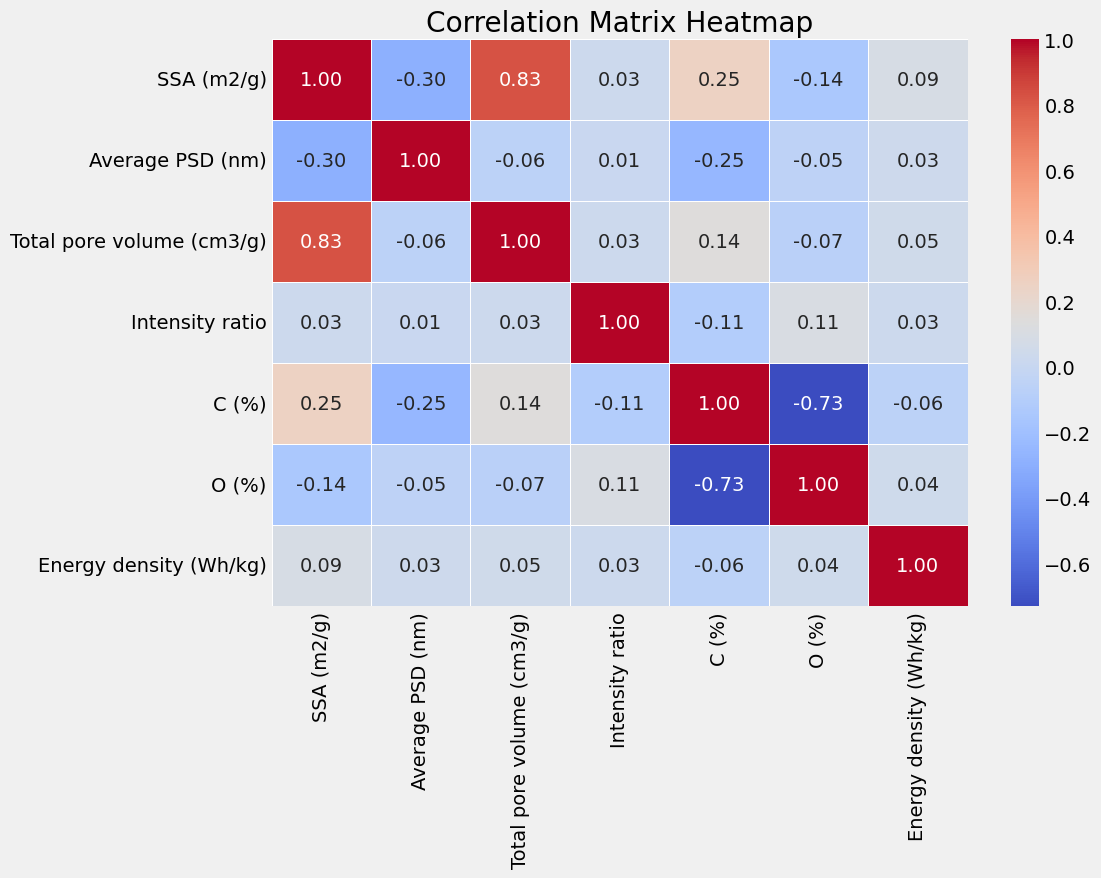

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select relevant columns
correlation_columns = ['SSA (m2/g)', 'Average PSD (nm)', 'Total pore volume (cm3/g)',
                       'Intensity ratio', 'C (%)', 'O (%)', 'Energy density (Wh/kg)']

# Ensure all relevant columns are numeric


# Ensure numeric and clean data
df_corr = df[correlation_columns].copy()
df_corr = df_corr.apply(pd.to_numeric, errors='coerce')
df_corr = df_corr.dropna()

# Compute the correlation matrix
corr_matrix = df_corr.corr()

# Plot heatmap
plt.figure(figsize=(10, 7))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix Heatmap")
plt.show()


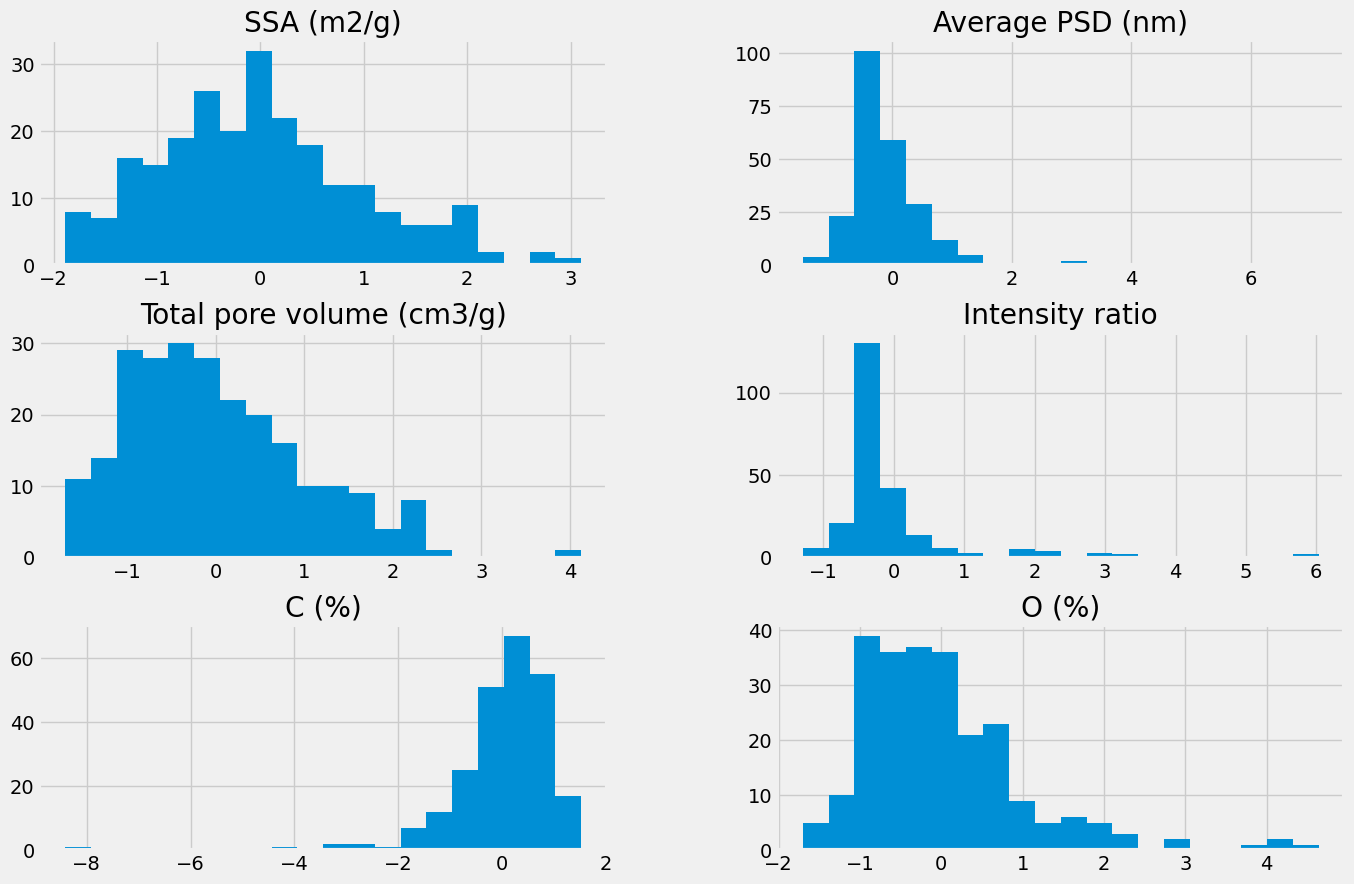

In [ ]:
df_scaled.hist(bins=20, figsize=(15, 10))
plt.show()

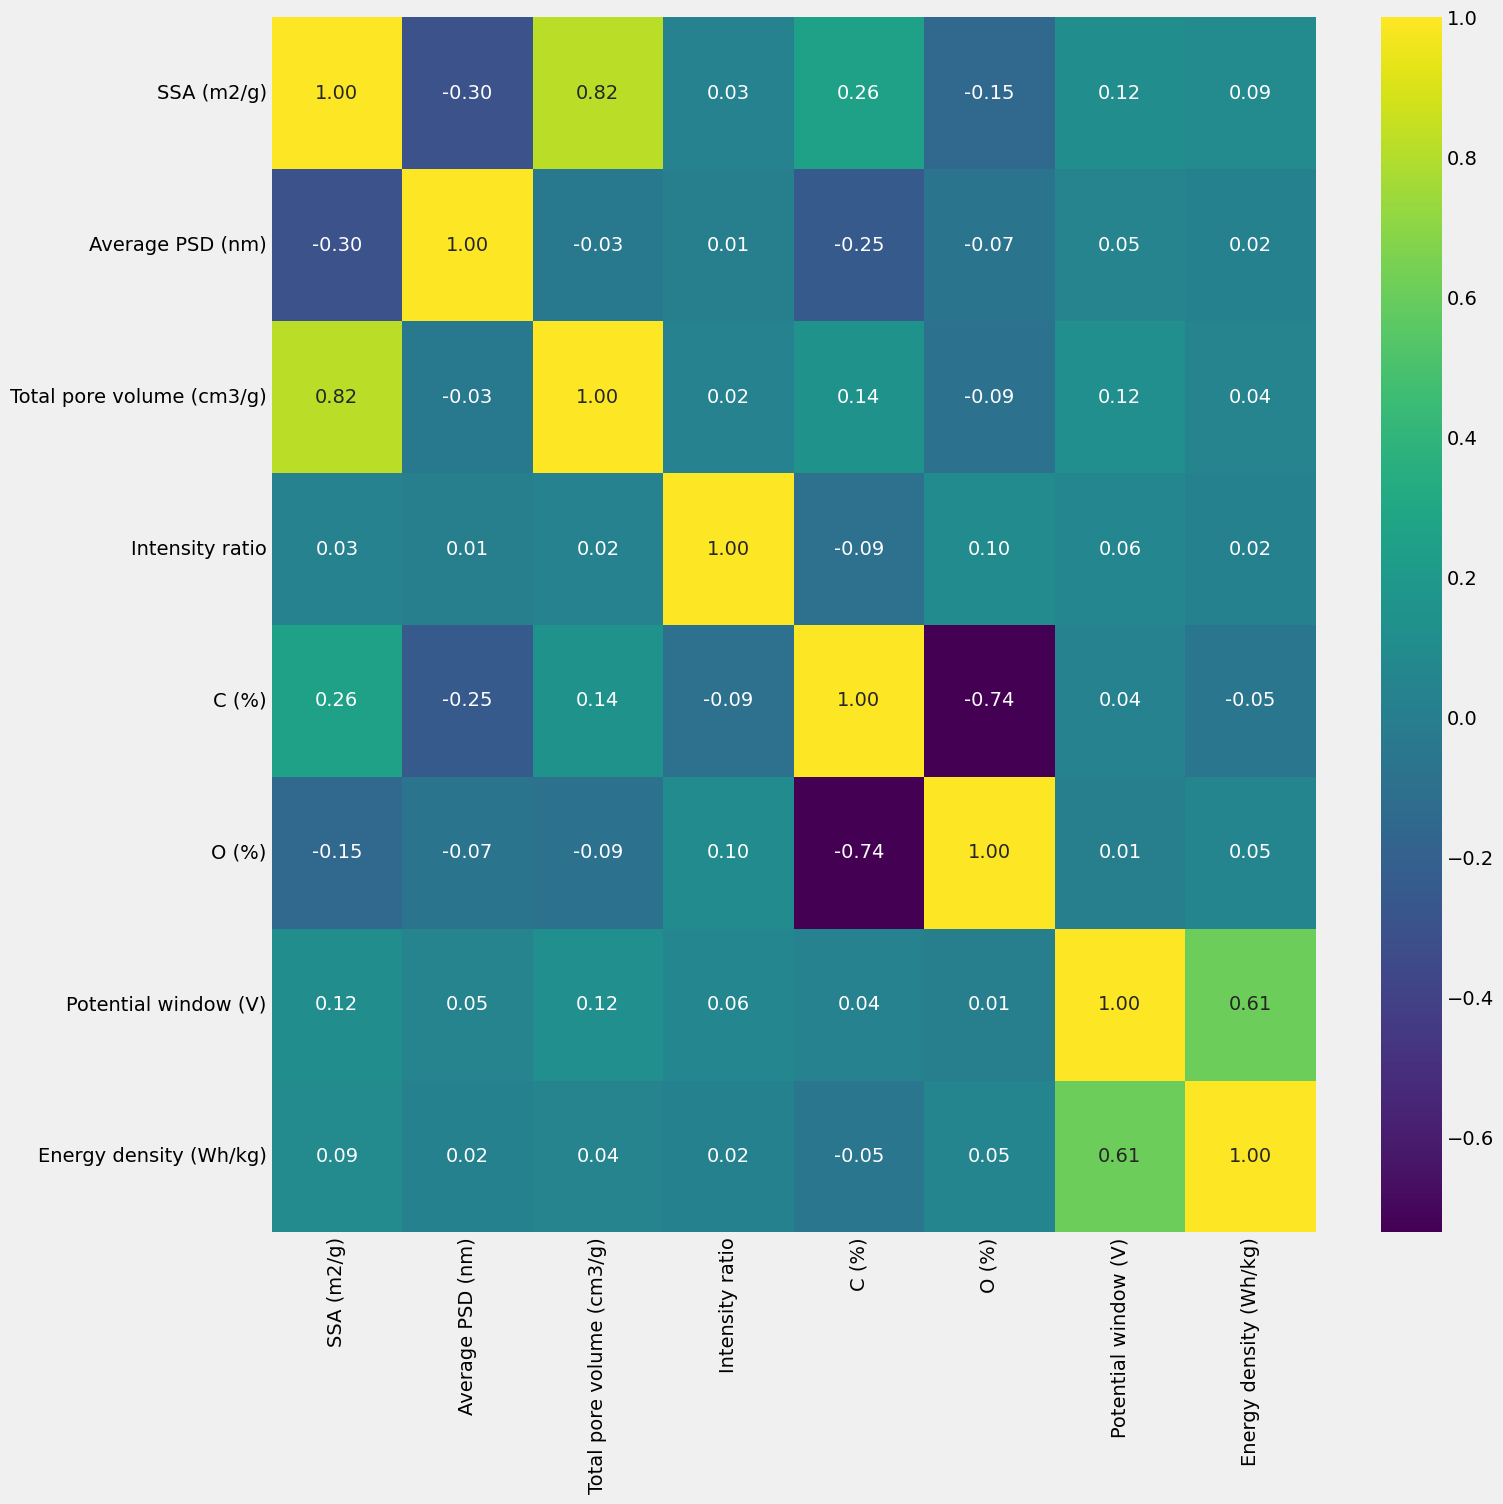

In [ ]:
#checking the correlation between the dataset,cmap='coolwarm'
correlation_matrix = df.corr()

# Increase the figure size
plt.figure(figsize=(15, 15))

# Plot the heatmap
sns.heatmap(correlation_matrix, cmap='viridis', annot=True , fmt=".2f")

# Show the plot
plt.show()


### Explanation
The provided image displays a correlation heatmap, illustrating the Pearson correlation coefficients between various features in the dataset, including Ambient Temp (°C), Panel Temp (°C), Irradiance (W/m²), Voltage (V), Current (A), and Power (W). The correlation coefficient, ranging from -1 to 1, quantifies the linear relationship between two variables: values close to 1 indicate a strong positive correlation, values close to -1 indicate a strong negative correlation, and values near 0 suggest no linear relationship.

Key Observations
Current (A) and Power (W): These features exhibit the highest positive correlation, with a coefficient of 0.8. This strong correlation suggests that as the current increases, the power output also tends to increase, which is consistent with the relationship between them.

Panel Temp (°C) and Ambient Temp (°C): The correlation between these two variables is 0.4, indicating a moderate positive relationship. This suggests that an increase in ambient temperature tends to raise the panel temperature, likely due to environmental heat transfer.

Other Relationships: Most other features display low to negligible correlations with one another, as indicated by coefficients close to zero. For example, the correlation between Irradiance (W/m²) and Voltage (V) is 0.0, suggesting no linear relationship between these variables in the dataset. Similarly, Ambient Temp (°C) shows very low correlations with all other variables except Panel Temp (°C), implying minimal direct linear influence on those variables.

Overall Low Correlations: Apart from the aforementioned pairs, the dataset exhibits generally low correlation coefficients, indicating that most features do not share strong linear relationships. This could imply that the system's output, specifically power generation, is influenced by a complex interplay of multiple factors rather than being strongly dependent on a single or pair of features.

Implications
The observed correlations an implications for subsequent data analysis and model building. The strong correlation between Current (A) and Power (W) suggests that models predicting power output should significantly consider the current as a feature. Conversely, the generally low correlations among other features indicate that linear models may not be sufficient to capture the underlying relationships in the data, suggesting the need for more complex models or feature engineering to uncover non-linear patterns. In case we consider to use Neural Network model() for complex feature detection to have effective system prediction. Additionally, the moderate correlation between Ambient Temp (°C) and Panel Temp (°C) may warrant consideration in thermal management or efficiency studies of photovoltaic systems.

###
The subsequent  code help us to visualize the most important feature as explain above. With the help of RandomForestRegressor from scikit-learning library

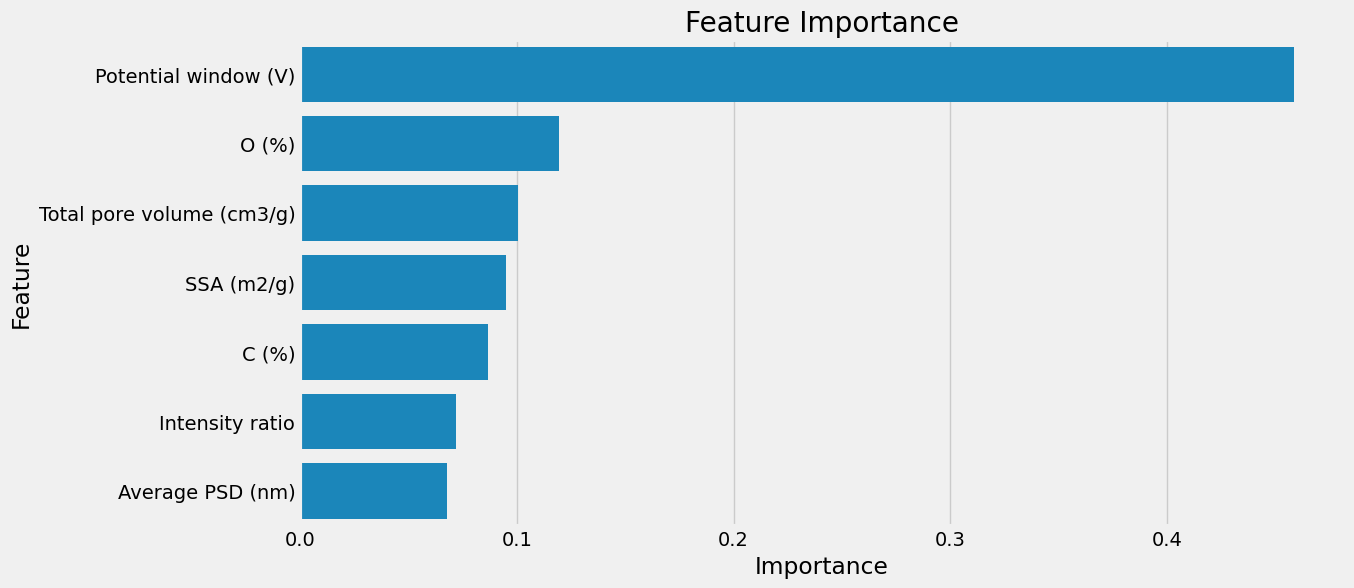

In [ ]:
from sklearn.ensemble import RandomForestRegressor
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns # Import seaborn for plotting

# Assuming df_clean is the DataFrame with rows containing NaNs in features or target dropped
# from the previous scaling step (cell Uh0ImY_VzoE6)

# Define features (X) and target (y) using the cleaned DataFrame
# Exclude the target column from features
X = df_clean.drop('Energy density (Wh/kg)', axis=1)
y = df_clean['Energy density (Wh/kg)']

# Create a Random Forest Regressor model
regressor = RandomForestRegressor(n_estimators=100, random_state=42)

# Train the model
regressor.fit(X, y)

# Display feature importance
feature_importances = regressor.feature_importances_
features = X.columns
feature_importance_df = pd.DataFrame({'Feature': features, 'Importance': feature_importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Plot the feature importances
plt.figure(figsize=(12, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.title('Feature Importance')
plt.show()

## Data spliting



In [ ]:
from sklearn.model_selection import train_test_split

# Assuming the DataFrame df now contains the relevant columns for regression

# Define X as all columns except the target variable 'Energy density (Wh/kg)'
# Define y as the target variable 'Energy density (Wh/kg)'

# Ensure 'Energy density (Wh/kg)' is present in df before dropping.
# If the original df was modified and 'Energy density (Wh/kg)' was removed, you need to reload or recreate df.
# For this fix, we assume 'Energy density (Wh/kg)' is present in df.

# Define X as all columns except the target variable 'Energy density (Wh/kg)'
X = df.drop('Energy density (Wh/kg)', axis=1)
y = df['Energy density (Wh/kg)']

# Split the data into training and test sets in 70 for training and 30 for evaluation
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Print shapes to confirm
print("Original data shape:", df.shape)
print("X shape:", X.shape)
print("y shape:", y.shape)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

Original data shape: (250, 8)
X shape: (250, 7)
y shape: (250,)
X_train shape: (175, 7)
X_test shape: (75, 7)
y_train shape: (175,)
y_test shape: (75,)


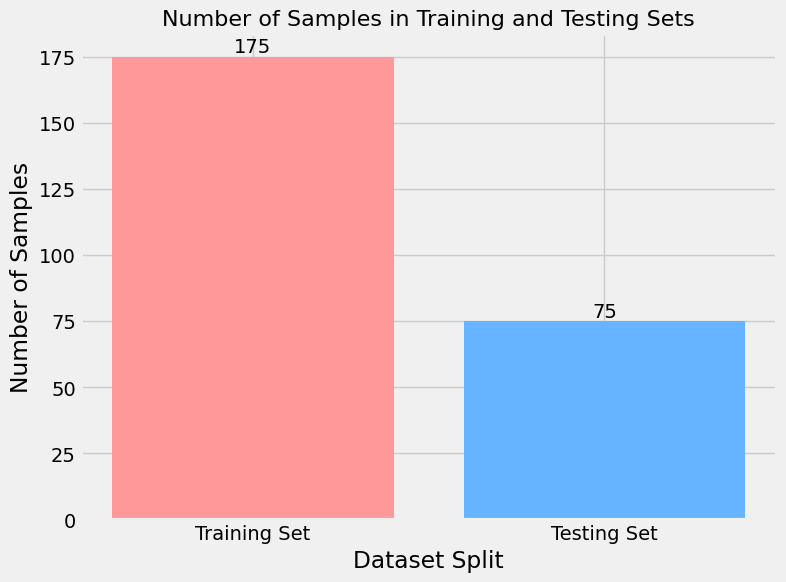

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd # Assuming df is a pandas DataFrame
import numpy as np # Needed for creating bar positions

# Assuming you have already executed the train_test_split and have X_train and X_test DataFrames/arrays
# You can get the number of samples from the shape of either X_train/X_test or y_train/y_test

# Get the number of samples in the training and testing sets
n_train = X_train.shape[0]
n_test = X_test.shape[0]

# Data for the bar chart
labels = ['Training Set', 'Testing Set']
counts = [n_train, n_test]
colors = ['#ff9999', '#66b3ff']

# Create the bar chart
plt.figure(figsize=(8, 6))
bars = plt.bar(labels, counts, color=colors)

# Add the number of samples on top of each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval, int(yval), va='bottom', ha='center') # va: vertical alignment, ha: horizontal alignment

# Add title and labels
plt.title('Number of Samples in Training and Testing Sets', fontsize=16)
plt.ylabel('Number of Samples')
plt.xlabel('Dataset Split')

plt.show()


### Training The Machine learning Models
#### Starting with Linear Regressior (LR)


## Importing the Neccessaryevaluation Metric


In [ ]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, mean_absolute_percentage_error

Training Performance Metrics:
MSE: 178.23926
RMSE: 13.35063
MAE: 8.84423
R²: 0.44478
MAPE: 77.19800%
NRMSE: 10.79580%

Testing Performance Metrics:
MSE: 181.53835
RMSE: 13.47362
MAE: 9.08440
R²: 0.15794
MAPE: 70.40385%
NRMSE: 21.45480%


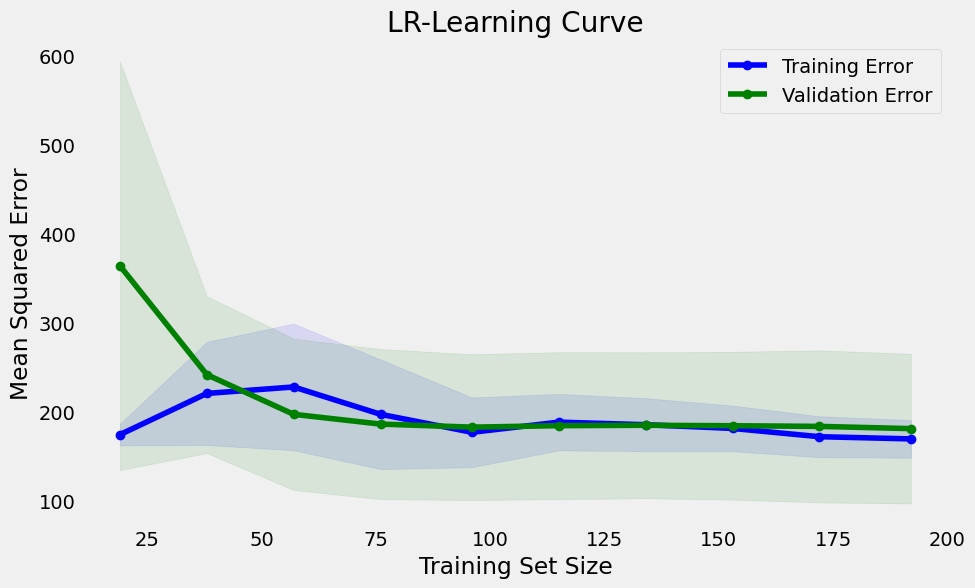

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split, learning_curve
import numpy as np
import matplotlib.pyplot as plt


# Exclude the 'Energy density (Wh/kg)' column from the features (X)
# Use the cleaned DataFrame df_clean
X = df_clean.drop(['Energy density (Wh/kg)'], axis=1)
y = df_clean['Energy density (Wh/kg)']


# Create synthetic data for regression with 53,298 samples
# This comment seems left over from a template, the actual data from df is used below


# Split the data into training (70%) and testing (30%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Create a Linear Regression model
model_lr = LinearRegression()

# Train the model on the training data
model_lr.fit(X_train, y_train)

# Get predictions on the training data
y_train_pred = model_lr.predict(X_train)

# Calculate performance metrics
# Mean Squared Error (MSE)
mse = mean_squared_error(y_train, y_train_pred)

# Root Mean Squared Error (RMSE)
rmse = np.sqrt(mse)

# Mean Absolute Error (MAE)
mae = mean_absolute_error(y_train, y_train_pred)

# R-squared (R²)
r2 = r2_score(y_train, y_train_pred)

# Mean Absolute Percentage Error (MAPE)
# Handle potential division by zero if y_train contains 0
mape = np.mean(np.abs((y_train - y_train_pred) / y_train.replace(0, np.nan))) * 100


# Normalized RMSE (NRMSE) in percentage
nrmse = (rmse / (y_train.max() - y_train.min())) * 100

# Print the results
print("Training Performance Metrics:")
print(f"MSE: {mse:.5f}")
print(f"RMSE: {rmse:.5f}")
print(f"MAE: {mae:.5f}")
print(f"R²: {r2:.5f}")
print(f"MAPE: {mape:.5f}%")
print(f"NRMSE: {nrmse:.5f}%")

# Evaluate on testing data
y_test_pred = model_lr.predict(X_test)
test_mse = mean_squared_error(y_test, y_test_pred)
test_rmse = np.sqrt(test_mse)
test_mae = mean_absolute_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)
# Handle potential division by zero if y_test contains 0
test_mape = np.mean(np.abs((y_test - y_test_pred) / y_test.replace(0, np.nan))) * 100

test_nrmse = (test_rmse / (y_test.max() - y_test.min())) * 100

# Print testing metrics
print("\nTesting Performance Metrics:")
print(f"MSE: {test_mse:.5f}")
print(f"RMSE: {test_rmse:.5f}")
print(f"MAE: {test_mae:.5f}")
print(f"R²: {test_r2:.5f}")
print(f"MAPE: {test_mape:.5f}%")
print(f"NRMSE: {test_nrmse:.5f}%")

# Learning Curve
train_sizes, train_scores, test_scores = learning_curve(
    model_lr, X, y, cv=5, scoring="neg_mean_squared_error", train_sizes=np.linspace(0.1, 1.0, 10), random_state=42
)

# Calculate mean and standard deviation of training and testing scores
train_mean = -np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = -np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# Plot learning curve
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, 'o-', color="blue", label="Training Error")
plt.plot(train_sizes, test_mean, 'o-', color="green", label="Validation Error")
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, color="blue", alpha=0.1)
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, color="green", alpha=0.1)
plt.title("LR-Learning Curve")
plt.xlabel("Training Set Size")
plt.ylabel("Mean Squared Error")
plt.legend(loc="best")
plt.grid()
plt.show()

In [ ]:
y_train

,Energy density (Wh/kg)
82,10.90
29,27.80
126,18.20
79,17.70
86,39.80
...,...
106,9.07
14,34.37
92,32.10
179,40.50


Training Performance Metrics:
MSE: 178.23926
RMSE: 13.35063
MAE: 8.84423
R²: 0.44478
MAPE: 77.19800%
NRMSE: 10.79580%

Testing Performance Metrics:
MSE: 181.53835
RMSE: 13.47362
MAE: 9.08440
R²: 0.15794
MAPE: 70.40385%
NRMSE: 21.45480%


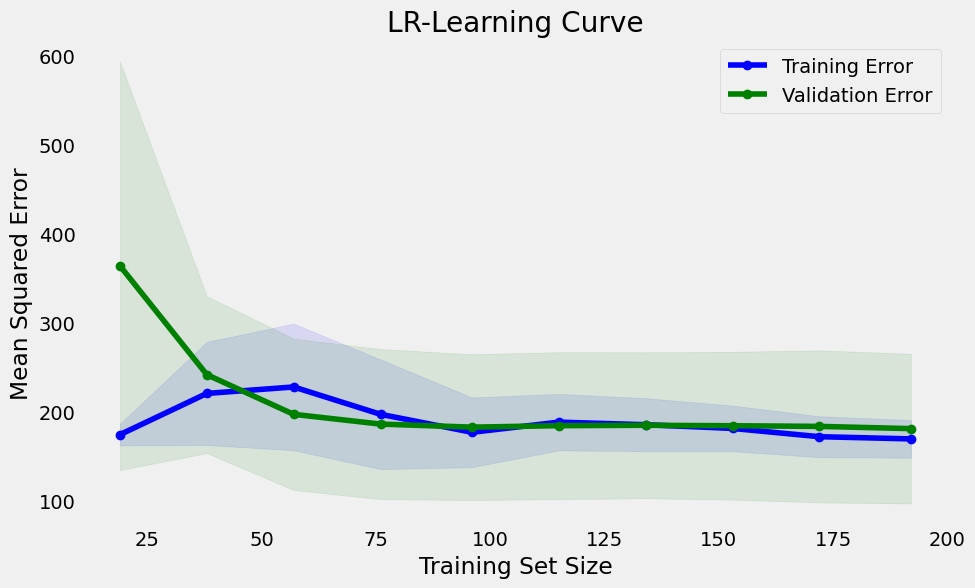

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split, learning_curve # Added learning_curve here
import numpy as np
import matplotlib.pyplot as plt # Import matplotlib for plotting

# Exclude the 'Energy density (Wh/kg)' column from the features (X)
# Assuming 'df' DataFrame is already loaded from previous steps
X = df_clean.drop(['Energy density (Wh/kg)'], axis=1)
y = df_clean['Energy density (Wh/kg)']


# Create synthetic data for regression with 53,298 samples
# This comment seems left over from a template, the actual data from df is used below


# Split the data into training (70%) and testing (30%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Create a Linear Regression model
model_lr = LinearRegression()

# Train the model on the training data
model_lr.fit(X_train, y_train)

# Get predictions on the training data
y_train_pred = model_lr.predict(X_train)

# Calculate performance metrics
# Mean Squared Error (MSE)
mse = mean_squared_error(y_train, y_train_pred)

# Root Mean Squared Error (RMSE)
rmse = np.sqrt(mse)

# Mean Absolute Error (MAE)
mae = mean_absolute_error(y_train, y_train_pred)

# R-squared (R²)
r2 = r2_score(y_train, y_train_pred)

# Mean Absolute Percentage Error (MAPE)
# Handle potential division by zero if y_train contains 0
mape = np.mean(np.abs((y_train - y_train_pred) / y_train.replace(0, np.nan))) * 100


# Normalized RMSE (NRMSE) in percentage
nrmse = (rmse / (y_train.max() - y_train.min())) * 100

# Print the results
print("Training Performance Metrics:")
print(f"MSE: {mse:.5f}")
print(f"RMSE: {rmse:.5f}")
print(f"MAE: {mae:.5f}")
print(f"R²: {r2:.5f}")
print(f"MAPE: {mape:.5f}%")
print(f"NRMSE: {nrmse:.5f}%")

# Evaluate on testing data
y_test_pred = model_lr.predict(X_test)
test_mse = mean_squared_error(y_test, y_test_pred)
test_rmse = np.sqrt(test_mse)
test_mae = mean_absolute_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)
# Handle potential division by zero if y_test contains 0
test_mape = np.mean(np.abs((y_test - y_test_pred) / y_test.replace(0, np.nan))) * 100

test_nrmse = (test_rmse / (y_test.max() - y_test.min())) * 100

# Print testing metrics
print("\nTesting Performance Metrics:")
print(f"MSE: {test_mse:.5f}")
print(f"RMSE: {test_rmse:.5f}")
print(f"MAE: {test_mae:.5f}")
print(f"R²: {test_r2:.5f}")
print(f"MAPE: {test_mape:.5f}%")
print(f"NRMSE: {test_nrmse:.5f}%")

# Learning Curve
train_sizes, train_scores, test_scores = learning_curve(
    model_lr, X, y, cv=5, scoring="neg_mean_squared_error", train_sizes=np.linspace(0.1, 1.0, 10), random_state=42
)

# Calculate mean and standard deviation of training and testing scores
train_mean = -np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = -np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# Plot learning curve
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, 'o-', color="blue", label="Training Error")
plt.plot(train_sizes, test_mean, 'o-', color="green", label="Validation Error")
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, color="blue", alpha=0.1)
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, color="green", alpha=0.1)
plt.title("LR-Learning Curve")
plt.xlabel("Training Set Size")
plt.ylabel("Mean Squared Error")
plt.legend(loc="best")
plt.grid()
plt.show()

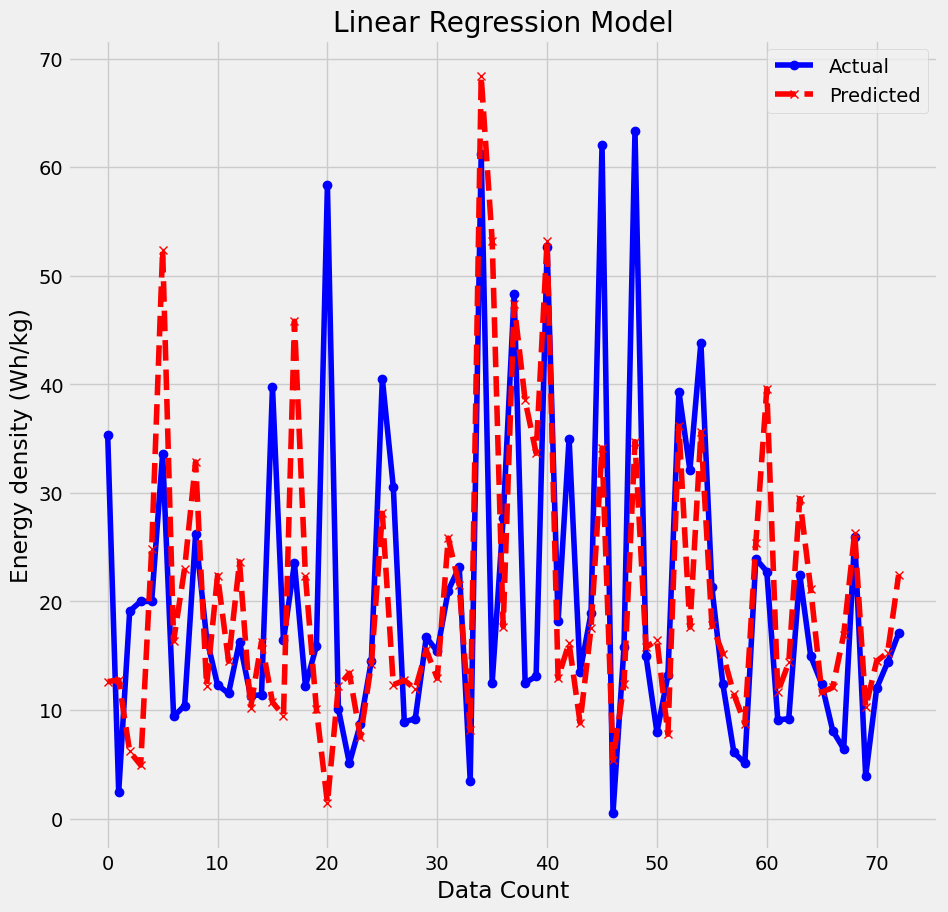

In [ ]:
print('\n')

plt.figure(figsize=(10, 10))
plt.plot(y_test.values, label='Actual', marker='o', linestyle='-', color='blue')
plt.plot(y_test_pred, label='Predicted', marker='x', linestyle='--', color='red')
plt.xlabel('Data Count')
plt.ylabel('Energy density (Wh/kg)')
plt.title('Linear Regression Model')
plt.legend()
plt.grid(True)
plt.show()

## RF Regressor

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split, learning_curve
# from sklearn.datasets import make_regression # Not needed here
import numpy as np
import pandas as pd # Ensure pandas is imported if it wasn't already

# Define X as all columns except the target variable 'Energy density (Wh/kg)' and the non-numerical 'Time' column
# Assuming 'df' DataFrame is already loaded and processed from previous steps
X = df_clean.drop(['Energy density (Wh/kg)'], axis=1)
y = df_clean['Energy density (Wh/kg)']


# Create synthetic data for regression with 53,298 samples
# This comment seems left over from a template, the actual data from df is used below


# Split the data into training (70%) and testing (30%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Create a Random Forest Regression model
model_rf = RandomForestRegressor(random_state=42)

# Train the model on the training data
model_rf.fit(X_train, y_train)

# Get predictions on the training data
y_train_pred = model_rf.predict(X_train)

# Calculate performance metrics
# Mean Squared Error (MSE)
mse = mean_squared_error(y_train, y_train_pred)

# Root Mean Squared Error (RMSE)
rmse = np.sqrt(mse)

# Mean Absolute Error (MAE)
mae = mean_absolute_error(y_train, y_train_pred)

# R-squared (R²)
r2 = r2_score(y_train, y_train_pred)

# Mean Absolute Percentage Error (MAPE)
# Handle potential division by zero if y_train contains 0
mape = np.mean(np.abs((y_train - y_train_pred) / y_train.replace(0, np.nan))) * 100


# Normalized RMSE (NRMSE) in percentage
nrmse = (rmse / (y_train.max() - y_train.min())) * 100

# Print the results
print("Training Performance Metrics:")
print(f"MSE: {mse:.5f}")
print(f"RMSE: {rmse:.5f}")
print(f"MAE: {mae:.5f}")
print(f"R²: {r2:.5f}")
print(f"MAPE: {mape:.5f}%")
print(f"NRMSE: {nrmse:.5f}%")

# Evaluate on testing data
y_test_pred = model_rf.predict(X_test)
test_mse = mean_squared_error(y_test, y_test_pred)
test_rmse = np.sqrt(test_mse)
test_mae = mean_absolute_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)
# Handle potential division by zero if y_test contains 0
test_mape = np.mean(np.abs((y_test - y_test_pred) / y_test.replace(0, np.nan))) * 100
test_nrmse = (test_rmse / (y_test.max() - y_test.min())) * 100

# Print testing metrics
print("\nTesting Performance Metrics:")
print(f"MSE: {test_mse:.5f}")
print(f"RMSE: {test_rmse:.5f}")
print(f"MAE: {test_mae:.5f}")
print(f"R²: {test_r2:.5f}")
print(f"MAPE: {test_mape:.5f}%")
print(f"NRMSE: {test_nrmse:.5f}%")

Training Performance Metrics:
MSE: 37.14223
RMSE: 6.09444
MAE: 3.69778
R²: 0.88430
MAPE: 53.73969%
NRMSE: 4.92819%

Testing Performance Metrics:
MSE: 213.79930
RMSE: 14.62188
MAE: 10.16588
R²: 0.00830
MAPE: 98.34055%
NRMSE: 23.28324%


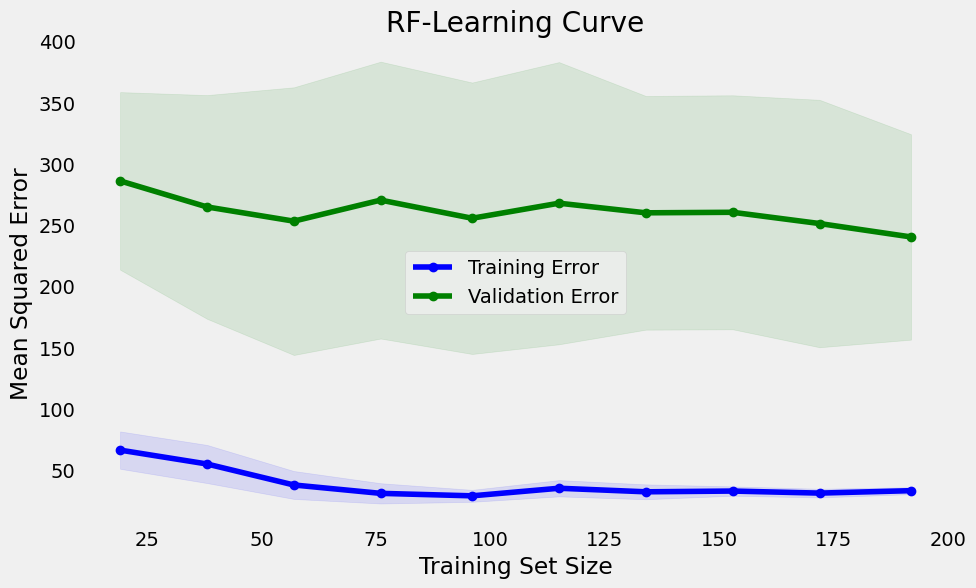

In [ ]:
# Learning Curve
train_sizes, train_scores, test_scores = learning_curve(
    model_rf, X, y, cv=5, scoring="neg_mean_squared_error", train_sizes=np.linspace(0.1, 1.0, 10), random_state=42
)

# Calculate mean and standard deviation of training and testing scores
train_mean = -np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = -np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# Plot learning curve
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, 'o-', color="blue", label="Training Error")
plt.plot(train_sizes, test_mean, 'o-', color="green", label="Validation Error")
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, color="blue", alpha=0.1)
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, color="green", alpha=0.1)
plt.title("RF-Learning Curve")
plt.xlabel("Training Set Size")
plt.ylabel("Mean Squared Error")
plt.legend(loc="best")
plt.grid()
plt.show()

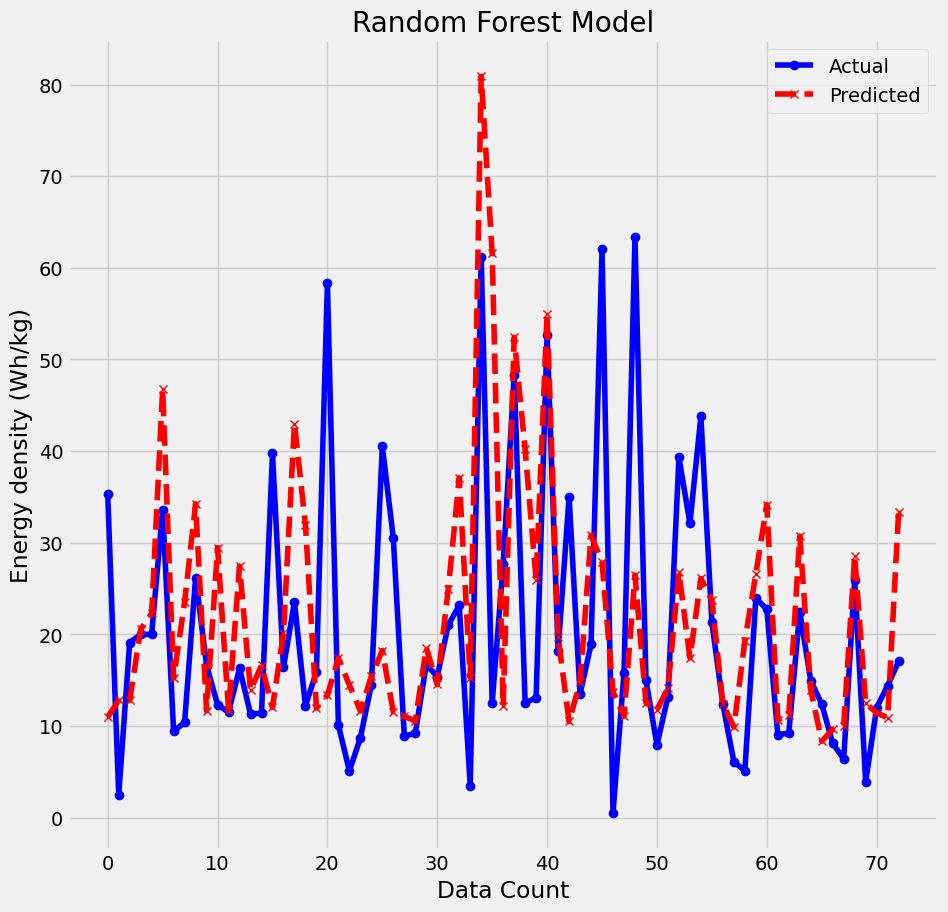

In [ ]:
print('\n')

plt.figure(figsize=(10, 10))
plt.plot(y_test.values, label='Actual', marker='o', linestyle='-', color='blue')
plt.plot(y_test_pred, label='Predicted', marker='x', linestyle='--', color='red')
plt.xlabel('Data Count')
plt.ylabel('Energy density (Wh/kg)')
plt.title('Random Forest Model')
plt.legend()
plt.grid(True)
plt.show()

y_pred_df = pd.DataFrame(y_test_pred, columns=['predicted power'])
y_pred_df.to_excel('RFoutput1.xlsx', index=False) # Changed y_pred to y_pred_df
y_test_df = pd.DataFrame(y_test.values, columns=['actual power'])
y_test_df.to_excel('RFoutput2.xlsx', index=False) # Changed y_pred to y_pred_df

## Training SVM model

In [ ]:
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import numpy as np
import pandas as pd # Ensure pandas is imported

# Define X as all columns except the target variable 'Energy density (Wh/kg)' and the non-numerical 'Time' column
# Assuming 'df' DataFrame is already loaded and processed from previous steps
# Drop both the target variable and the 'Time' column from the features X
X = df_clean.drop(['Energy density (Wh/kg)'], axis=1)
y = df_clean['Energy density (Wh/kg)']

# Split the data into training (70%) and testing (30%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Standardize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Reduce dimensionality with PCA
# Adjust n_components based on the number of features after dropping 'Time'
# Assuming the other columns are numerical, there are 5 features left ('Ambient Temp (°C)', 'Panel Temp (°C)', 'Irradiance (W/m²)', 'Voltage (V)', 'Current (A)')
# Set n_components to be at most the number of features (5)
pca = PCA(n_components=X_train_scaled.shape[1]) # Use the actual number of features after dropping 'Energy density (Wh/kg)'
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# Create a Support Vector Regression (SVR) model with RBF kernel
model_svr = SVR(kernel='rbf', C=1.0, epsilon=0.1)

# Train the model on the training data
model_svr.fit(X_train_pca, y_train)

# Get predictions on the training data
y_train_pred = model_svr.predict(X_train_pca)

# Calculate performance metrics for training data
mse_train = mean_squared_error(y_train, y_train_pred)
rmse_train = np.sqrt(mse_train)
mae_train = mean_absolute_error(y_train, y_train_pred)
r2_train = r2_score(y_train, y_train_pred)
# Handle potential division by zero if y_train contains 0
mape_train = np.mean(np.abs((y_train - y_train_pred) / y_train.replace(0, np.nan))) * 100

nrmse_train = (rmse_train / (y_train.max() - y_train.min())) * 100

# Print training metrics
print("Training Performance Metrics:")
print(f"MSE: {mse_train:.5f}")
print(f"RMSE: {rmse_train:.5f}")
print(f"MAE: {mae_train:.5f}")
print(f"R²: {r2_train:.5f}")
print(f"MAPE: {mape_train:.5f}%")
print(f"NRMSE: {nrmse_train:.5f}%")

# Evaluate on testing data
y_test_pred = model_svr.predict(X_test_pca)
mse_test = mean_squared_error(y_test, y_test_pred)
rmse_test = np.sqrt(mse_test)
mae_test = mean_absolute_error(y_test, y_test_pred)
r2_test = r2_score(y_test, y_test_pred)
# Handle potential division by zero if y_test contains 0
test_mape = np.mean(np.abs((y_test - y_test_pred) / y_test.replace(0, np.nan))) * 100
nrmse_test = (rmse_test / (y_test.max() - y_test.min())) * 100

# Print testing metrics
print("\nTesting Performance Metrics:")
print(f"MSE: {mse_test:.5f}")
print(f"RMSE: {test_rmse:.5f}")
print(f"MAE: {test_mae:.5f}")
print(f"R²: {test_r2:.5f}")
print(f"MAPE: {test_mape:.5f}%")
print(f"NRMSE: {nrmse_test:.5f}%")

Training Performance Metrics:
MSE: 295.42725
RMSE: 17.18800
MAE: 9.12037
R²: 0.07974
MAPE: 82.09415%
NRMSE: 13.89884%

Testing Performance Metrics:
MSE: 193.70903
RMSE: 14.62188
MAE: 10.16588
R²: 0.00830
MAPE: 74.17780%
NRMSE: 22.16232%


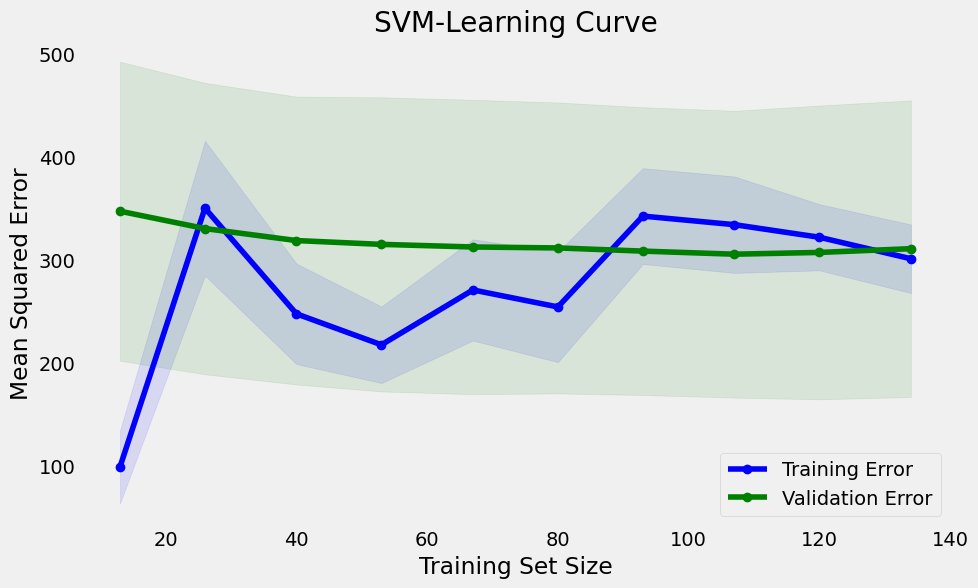

In [ ]:
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt
import numpy as np

# Learning Curve for SVR
train_sizes, train_scores, test_scores = learning_curve(
    model_svr,
    X_train_pca, # Use PCA transformed data for learning curve
    y_train,
    cv=5,
    scoring="neg_mean_squared_error",
    train_sizes=np.linspace(0.1, 1.0, 10),
    random_state=42,
    n_jobs=-1
)

# Calculate mean and standard deviation
train_mean = -np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = -np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# Plot learning curve
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, 'o-', color="blue", label="Training Error")
plt.plot(train_sizes, test_mean, 'o-', color="green", label="Validation Error")
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, color="blue", alpha=0.1)
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, color="green", alpha=0.1)
plt.title("SVM-Learning Curve")
plt.xlabel("Training Set Size")
plt.ylabel("Mean Squared Error")
plt.legend(loc="best")
plt.grid()
plt.show()

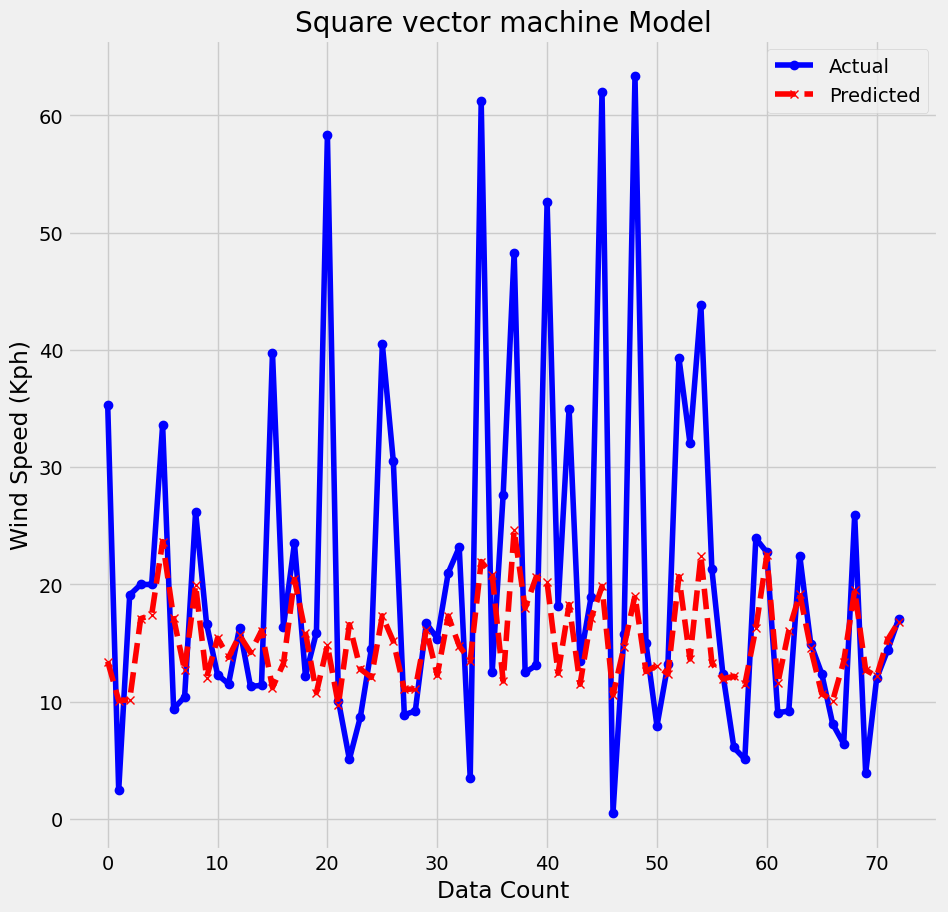

In [ ]:
print('\n')

plt.figure(figsize=(10, 10))
plt.plot(y_test.values, label='Actual', marker='o', linestyle='-', color='blue')
plt.plot(y_test_pred, label='Predicted', marker='x', linestyle='--', color='red')
plt.xlabel('Data Count')
plt.ylabel('Wind Speed (Kph)')
plt.title('Square vector machine Model')
plt.legend()
plt.grid(True)
plt.show()

y_pred_df = pd.DataFrame(y_test_pred, columns=['predicted power'])
y_pred_df.to_excel('SVMoutput1.xlsx', index=False) # Changed y_pred to y_pred_df
y_test_df = pd.DataFrame(y_test.values, columns=['actual power'])
y_test_df.to_excel('SVMoutput2.xlsx', index=False) # Changed y_pred to y_pred_df

## Training Decision Tree Regressor

In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split, learning_curve
# from sklearn.datasets import make_regression # This line is commented out and not needed
import numpy as np
import pandas as pd # Ensure pandas is imported if not already

# Assuming 'df' DataFrame is already loaded from previous steps

# Define X as all columns except the target variable 'Energy density (Wh/kg)' and the 'Time' column
# Drop both the target variable and the 'Time' column from the features X
X = df_clean.drop(['Energy density (Wh/kg)'], axis=1) # Exclude 'Time' here
y = df_clean['Energy density (Wh/kg)']


# Create synthetic data for regression with 53,298 samples
# This comment seems left over from a template, the actual data from df is used below


# Split the data into training (70%) and testing (30%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Create a Decision Tree Regression model
model_dt = DecisionTreeRegressor(max_depth=5, random_state=42)

# Train the model on the training data
model_dt.fit(X_train, y_train)

# Get predictions on the training data
y_train_pred = model_dt.predict(X_train)

# Calculate performance metrics
# Mean Squared Error (MSE)
mse = mean_squared_error(y_train, y_train_pred)

# Root Mean Squared Error (RMSE)
rmse = np.sqrt(mse)

# Mean Absolute Error (MAE)
mae = mean_absolute_error(y_train, y_train_pred)

# R-squared (R²)
r2 = r2_score(y_train, y_train_pred)

# Mean Absolute Percentage Error (MAPE)
# Handle potential division by zero if y_train contains 0
mape = np.mean(np.abs((y_train - y_train_pred) / y_train.replace(0, np.nan))) * 100

# Normalized RMSE (NRMSE) in percentage
nrmse = (rmse / (y_train.max() - y_train.min())) * 100

# Print the results
print("Training Performance Metrics:")
print(f"MSE: {mse:.5f}")
print(f"RMSE: {rmse:.5f}")
print(f"MAE: {mae:.5f}")
print(f"R²: {r2:.5f}")
print(f"MAPE: {mape:.5f}%")
print(f"NRMSE: {nrmse:.5f}%")

# Evaluate on testing data
y_test_pred = model_dt.predict(X_test)
test_mse = mean_squared_error(y_test, y_test_pred)
test_rmse = np.sqrt(test_mse)
test_mae = mean_absolute_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)
# Handle potential division by zero if y_test contains 0
test_mape = np.mean(np.abs((y_test - y_test_pred) / y_test.replace(0, np.nan))) * 100
test_nrmse = (test_rmse / (y_test.max() - y_test.min())) * 100

# Print testing metrics
print("\nTesting Performance Metrics:")
print(f"MSE: {test_mse:.5f}")
print(f"RMSE: {test_rmse:.5f}")
print(f"MAE: {test_mae:.5f}")
print(f"R²: {test_r2:.5f}")
print(f"MAPE: {test_mape:.5f}%")
print(f"NRMSE: {test_nrmse:.5f}%")

Training Performance Metrics:
MSE: 59.15023
RMSE: 7.69092
MAE: 5.27583
R²: 0.81575
MAPE: 52.75522%
NRMSE: 6.21916%

Testing Performance Metrics:
MSE: 701.73669
RMSE: 26.49031
MAE: 15.48506
R²: -2.25499
MAPE: 151.76053%
NRMSE: 42.18203%


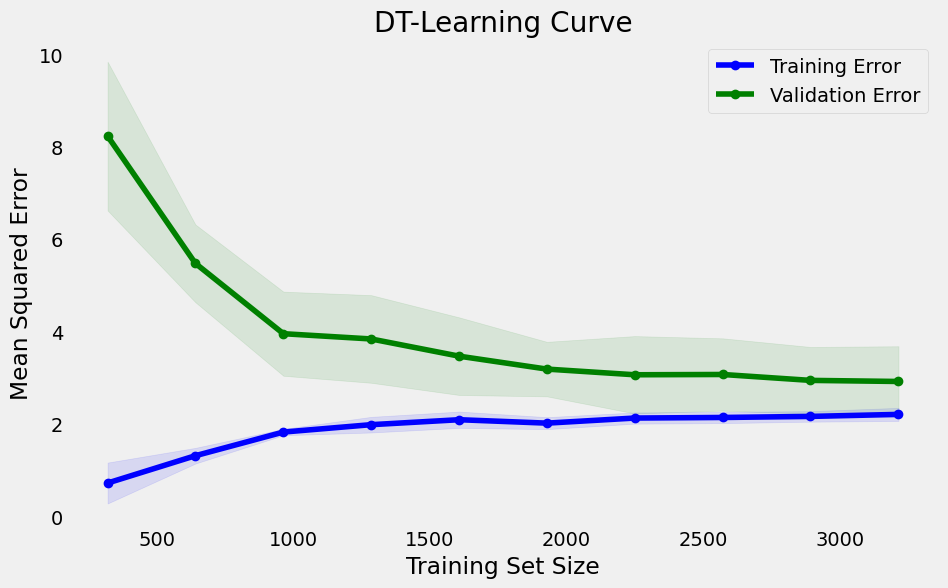

In [ ]:
# Learning Curve
train_sizes, train_scores, test_scores = learning_curve(
    model_dt, X, y, cv=5, scoring="neg_mean_squared_error", train_sizes=np.linspace(0.1, 1.0, 10), random_state=42
)

# Calculate mean and standard deviation of training and testing scores
train_mean = -np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = -np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# Plot learning curve
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, 'o-', color="blue", label="Training Error")
plt.plot(train_sizes, test_mean, 'o-', color="green", label="Validation Error")
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, color="blue", alpha=0.1)
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, color="green", alpha=0.1)
plt.title("DT-Learning Curve")
plt.xlabel("Training Set Size")
plt.ylabel("Mean Squared Error")
plt.legend(loc="best")
plt.grid()
plt.show()

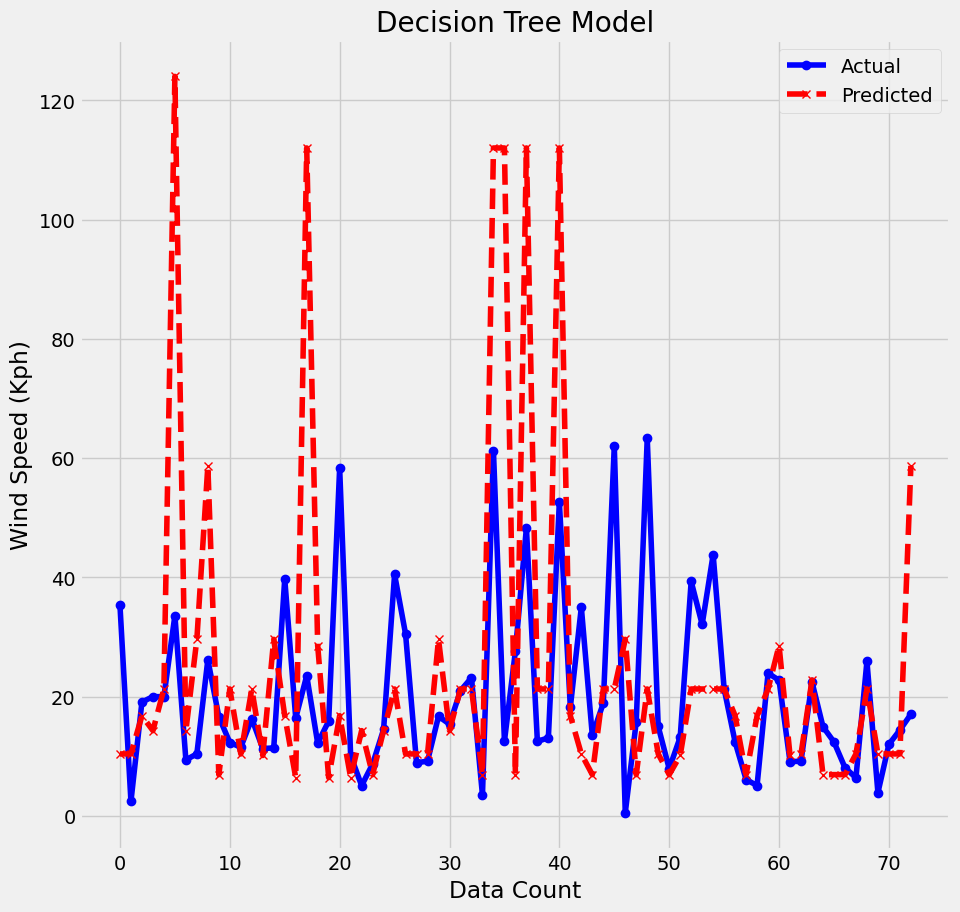

In [ ]:
plt.figure(figsize=(10, 10))
plt.plot(y_test.values, label='Actual', marker='o', linestyle='-', color='blue')
plt.plot(y_test_pred, label='Predicted', marker='x', linestyle='--', color='red')
plt.xlabel('Data Count')
plt.ylabel('Wind Speed (Kph)')
plt.title('Decision Tree Model')
plt.legend()
plt.grid(True)
plt.show()

y_pred_df = pd.DataFrame(y_test_pred, columns=['predicted power'])
y_pred_df.to_excel('DToutput1.xlsx', index=False) # Changed y_pred to y_pred_df
y_test_df = pd.DataFrame(y_test.values, columns=['actual power'])
y_test_df.to_excel('DToutput2.xlsx', index=False) # Changed y_pred to y_pred_df

## Training K-Nearest Neighbors Regressors

In [ ]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.datasets import make_regression
import numpy as np
import pandas as pd # Ensure pandas is imported

# Assuming 'df' DataFrame is already loaded from previous steps

# Define X as all columns except the target variable 'Energy density (Wh/kg)' and the non-numerical 'Time' column
# Drop both the target variable and the 'Time' column from the features X
X = df_clean.drop(['Energy density (Wh/kg)'], axis=1) # Exclude 'Time' here
y = df_clean['Energy density (Wh/kg)']

# Create synthetic data for regression with 53,298 samples
# This comment seems left over from a template, the actual data from df is used below

# Split the data into training (70%) and testing (30%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Create a K Neighbor Regression model
model_knn = KNeighborsRegressor()

# Train the model on the training data
model_knn.fit(X_train, y_train)

# Get predictions on the training data
y_train_pred = model_knn.predict(X_train)

# Calculate performance metrics
# Mean Squared Error (MSE)
mse = mean_squared_error(y_train, y_train_pred)

# Root Mean Squared Error (RMSE)
rmse = np.sqrt(mse)

# Mean Absolute Error (MAE)
mae = mean_absolute_error(y_train, y_train_pred)

# R-squared (R²)
r2 = r2_score(y_train, y_train_pred)

# Mean Absolute Percentage Error (MAPE)
# Handle potential division by zero if y_train contains 0
# Replace 0 values in y_train with NaN before calculating MAPE to avoid division by zero
mape = np.mean(np.abs((y_train - y_train_pred) / y_train.replace(0, np.nan).dropna())) * 100


# Normalized RMSE (NRMSE) in percentage
nrmse = (rmse / (y_train.max() - y_train.min())) * 100

# Print the results
print("Training Performance Metrics:")
print(f"MSE: {mse:.5f}")
print(f"RMSE: {rmse:.5f}")
print(f"MAE: {mae:.5f}")
print(f"R²: {r2:.5f}")
print(f"MAPE: {mape:.5f}%")
print(f"NRMSE: {nrmse:.5f}%")

# Evaluate on testing data
y_test_pred = model_knn.predict(X_test)
test_mse = mean_squared_error(y_test, y_test_pred)
test_rmse = np.sqrt(test_mse)
test_mae = mean_absolute_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)
# Handle potential division by zero if y_test contains 0
# Replace 0 values in y_test with NaN before calculating MAPE to avoid division by zero
test_mape = np.mean(np.abs((y_test - y_test_pred) / y_test.replace(0, np.nan).dropna())) * 100
test_nrmse = (test_rmse / (y_test.max() - y_test.min())) * 100

# Print testing metrics
print("\nTesting Performance Metrics:")
print(f"MSE: {test_mse:.5f}")
print(f"RMSE: {test_rmse:.5f}")
print(f"MAE: {test_mae:.5f}")
print(f"R²: {test_r2:.5f}")
print(f"MAPE: {test_mape:.5f}%")
print(f"NRMSE: {test_nrmse:.5f}%")

Training Performance Metrics:
MSE: 264.59662
RMSE: 16.26643
MAE: 10.58762
R²: 0.17577
MAPE: 172.64008%
NRMSE: 13.15362%

Testing Performance Metrics:
MSE: 258.77655
RMSE: 16.08653
MAE: 12.51595
R²: -0.20033
MAPE: 132.21087%
NRMSE: 25.61550%


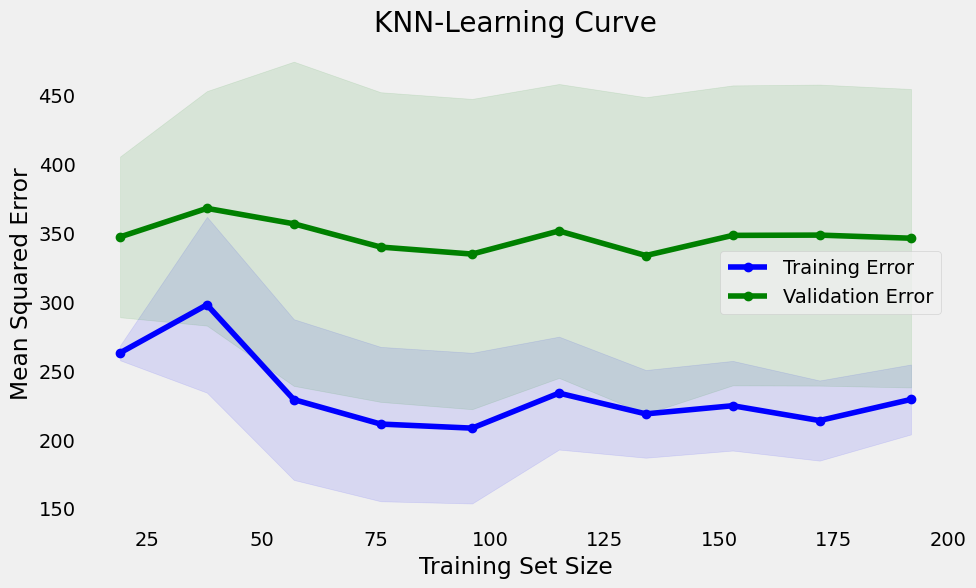

In [ ]:
# Learning Curve
train_sizes, train_scores, test_scores = learning_curve(
    model_knn, X, y, cv=5, scoring="neg_mean_squared_error", train_sizes=np.linspace(0.1, 1.0, 10), random_state=42
)

# Calculate mean and standard deviation of training and testing scores
train_mean = -np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = -np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# Plot learning curve
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, 'o-', color="blue", label="Training Error")
plt.plot(train_sizes, test_mean, 'o-', color="green", label="Validation Error")
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, color="blue", alpha=0.1)
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, color="green", alpha=0.1)
plt.title("KNN-Learning Curve")
plt.xlabel("Training Set Size")
plt.ylabel("Mean Squared Error")
plt.legend(loc="best")
plt.grid()
plt.show()

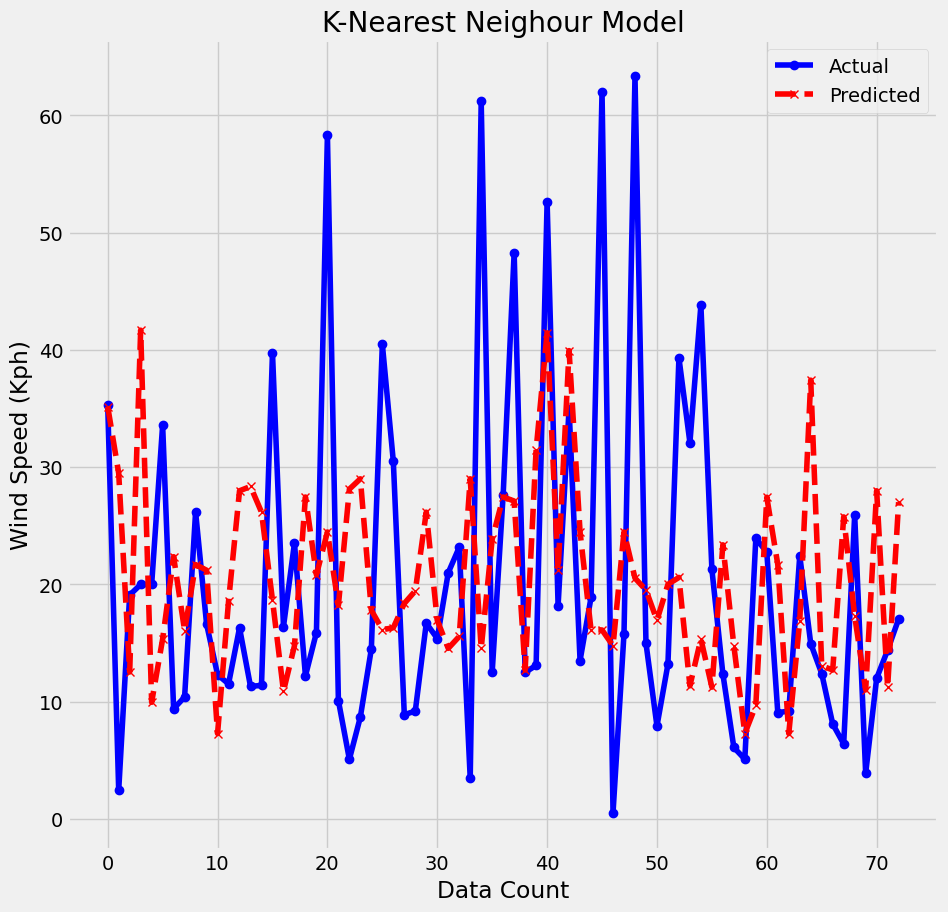

In [ ]:
plt.figure(figsize=(10, 10))
plt.plot(y_test.values, label='Actual', marker='o', linestyle='-', color='blue')
plt.plot(y_test_pred, label='Predicted', marker='x', linestyle='--', color='red')
plt.xlabel('Data Count')
plt.ylabel('Wind Speed (Kph)')
plt.title('K-Nearest Neighour Model')
plt.legend()
plt.grid(True)
plt.show()

y_pred_df = pd.DataFrame(y_test_pred, columns=['predicted power'])
y_pred_df.to_excel('KNNoutput1.xlsx', index=False) # Changed y_pred to y_pred_df
y_test_df = pd.DataFrame(y_test.values, columns=['actual power'])
y_test_df.to_excel('KNNoutput2.xlsx', index=False) # Changed y_pred to y_pred_df

## Training Lasso Regressor

In [ ]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.datasets import make_regression
import numpy as np


# Define X as all columns except the target variable 'Energy density (Wh/kg)' AND the 'Time' column
# This was the line causing the error in the original code for Lasso
# X = df.drop('Wind Speed (Kph)', axis=1)
X = df_clean.drop(['Energy density (Wh/kg)'], axis=1) # Corrected line to exclude 'Time'

y = df_clean['Energy density (Wh/kg)']


# Create synthetic data for regression with 53,298 samples
# This comment seems left over from a template, the actual data from df is used below


# Split the data into training (70%) and testing (30%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Create a Lasso Regression model
model_ls = Lasso()

# Train the model on the training data
model_ls.fit(X_train, y_train)

# Get predictions on the training data
y_train_pred = model_ls.predict(X_train)

# Calculate performance metrics
# Mean Squared Error (MSE)
mse = mean_squared_error(y_train, y_train_pred)

# Root Mean Squared Error (RMSE)
rmse = np.sqrt(mse)

# Mean Absolute Error (MAE)
mae = mean_absolute_error(y_train, y_train_pred)

# R-squared (R²)
r2 = r2_score(y_train, y_train_pred)

# Mean Absolute Percentage Error (MAPE)
# Handle potential division by zero if y_train contains 0
mape = np.mean(np.abs((y_train - y_train_pred) / y_train.replace(0, np.nan).dropna())) * 100 # Added .dropna() as in KNN


# Normalized RMSE (NRMSE) in percentage
nrmse = (rmse / (y_train.max() - y_train.min())) * 100

# Print the results
print("Training Performance Metrics:")
print(f"MSE: {mse:.5f}")
print(f"RMSE: {rmse:.5f}")
print(f"MAE: {mae:.5f}")
print(f"R²: {r2:.5f}")
print(f"MAPE: {mape:.5f}%")
print(f"NRMSE: {nrmse:.5f}%")

# Evaluate on testing data
y_test_pred = model_ls.predict(X_test)
test_mse = mean_squared_error(y_test, y_test_pred)
test_rmse = np.sqrt(test_mse)
test_mae = mean_absolute_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)
# Handle potential division by zero if y_test contains 0
test_mape = np.mean(np.abs((y_test - y_test_pred) / y_test.replace(0, np.nan).dropna())) * 100 # Added .dropna() as in KNN
test_nrmse = (test_rmse / (y_test.max() - y_test.min())) * 100

# Print testing metrics
print("\nTesting Performance Metrics:")
print(f"MSE: {test_mse:.5f}")
print(f"RMSE: {test_rmse:.5f}")
print(f"MAE: {test_mae:.5f}")
print(f"R²: {test_r2:.5f}")
print(f"MAPE: {test_mape:.5f}%")
print(f"NRMSE: {test_nrmse:.5f}%")

Training Performance Metrics:
MSE: 187.97611
RMSE: 13.71044
MAE: 9.02863
R²: 0.41445
MAPE: 86.43038%
NRMSE: 11.08676%

Testing Performance Metrics:
MSE: 149.53499
RMSE: 12.22845
MAE: 8.44264
R²: 0.30639
MAPE: 77.67937%
NRMSE: 19.47205%


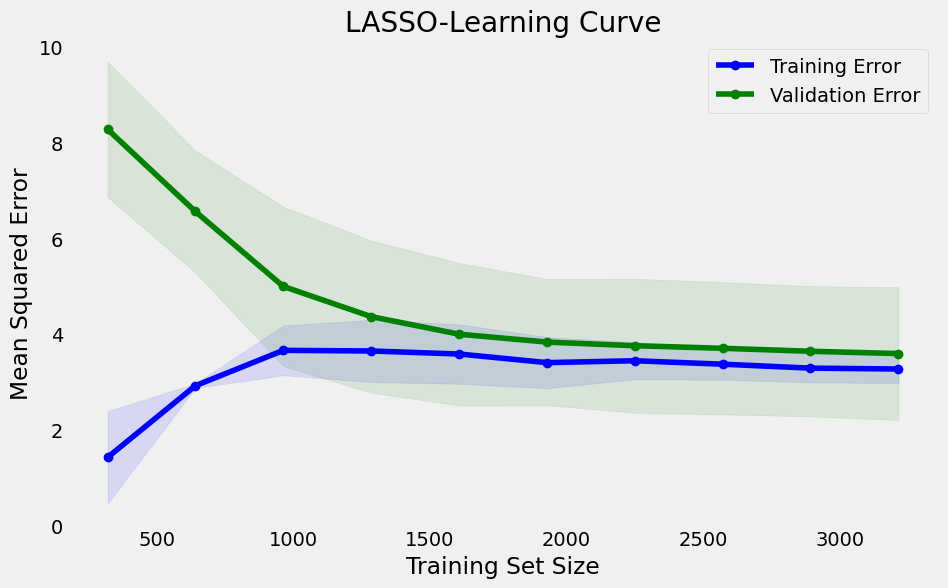

In [ ]:
# Learning Curve
train_sizes, train_scores, test_scores = learning_curve(
    model_ls, X, y, cv=5, scoring="neg_mean_squared_error", train_sizes=np.linspace(0.1, 1.0, 10), random_state=42
)

# Calculate mean and standard deviation of training and testing scores
train_mean = -np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = -np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# Plot learning curve
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, 'o-', color="blue", label="Training Error")
plt.plot(train_sizes, test_mean, 'o-', color="green", label="Validation Error")
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, color="blue", alpha=0.1)
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, color="green", alpha=0.1)
plt.title("LASSO-Learning Curve")
plt.xlabel("Training Set Size")
plt.ylabel("Mean Squared Error")
plt.legend(loc="best")
plt.grid()
plt.show()

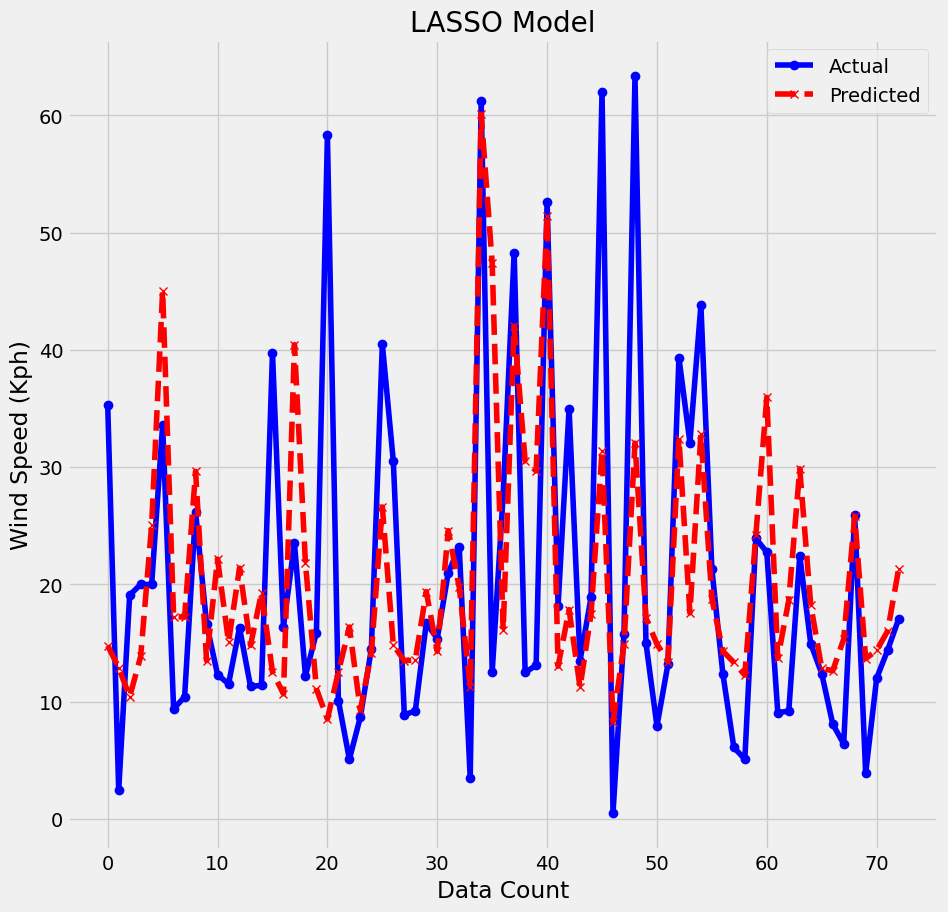

In [ ]:
plt.figure(figsize=(10, 10))
plt.plot(y_test.values, label='Actual', marker='o', linestyle='-', color='blue')
plt.plot(y_test_pred, label='Predicted', marker='x', linestyle='--', color='red')
plt.xlabel('Data Count')
plt.ylabel('Wind Speed (Kph)')
plt.title('LASSO Model')
plt.legend()
plt.grid(True)
plt.show()

y_pred_df = pd.DataFrame(y_test_pred, columns=['predicted power'])
y_pred_df.to_excel('LASSOoutput1.xlsx', index=False) # Changed y_pred to y_pred_df
y_test_df = pd.DataFrame(y_test.values, columns=['actual power'])
y_test_df.to_excel('LASSOoutput2.xlsx', index=False) # Changed y_pred to y_pred_df

## Training Ridge Regressor

In [ ]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split, learning_curve
import numpy as np
import pandas as pd # Ensure pandas is imported

# Define X as all columns except the target variable 'Energy density (Wh/kg)' AND the 'Time' column
# The 'Time' column must be excluded because it's not numerical
X = df_clean.drop(['Energy density (Wh/kg)'], axis=1)

y = df_clean['Energy density (Wh/kg)']

# Split the data into training (70%) and testing (30%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Create a Ridge Regression model
model_rg = Ridge()

# Train the model on the training data
model_rg.fit(X_train, y_train)

# Get predictions on the training data
y_train_pred = model_rg.predict(X_train)

# Calculate performance metrics
# Mean Squared Error (MSE)
mse = mean_squared_error(y_train, y_train_pred)

# Root Mean Squared Error (RMSE)
rmse = np.sqrt(mse)

# Mean Absolute Error (MAE)
mae = mean_absolute_error(y_train, y_train_pred)

# R-squared (R²)
r2 = r2_score(y_train, y_train_pred)

# Mean Absolute Percentage Error (MAPE)
# Handle potential division by zero if y_train contains 0
mape = np.mean(np.abs((y_train - y_train_pred) / y_train.replace(0, np.nan).dropna())) * 100 # Added .dropna() for robustness


# Normalized RMSE (NRMSE) in percentage
nrmse = (rmse / (y_train.max() - y_train.min())) * 100

# Print the results
print("Training Performance Metrics:")
print(f"MSE: {mse:.5f}")
print(f"RMSE: {rmse:.5f}")
print(f"MAE: {mae:.5f}")
print(f"R²: {r2:.5f}")
print(f"MAPE: {mape:.5f}%")
print(f"NRMSE: {nrmse:.5f}%")

# Evaluate on testing data
y_test_pred = model_rg.predict(X_test)
test_mse = mean_squared_error(y_test, y_test_pred)
test_rmse = np.sqrt(test_mse)
test_mae = mean_absolute_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)
# Handle potential division by zero if y_test contains 0
test_mape = np.mean(np.abs((y_test - y_test_pred) / y_test.replace(0, np.nan).dropna())) * 100 # Added .dropna() for robustness
test_nrmse = (test_rmse / (y_test.max() - y_test.min())) * 100

# Print testing metrics
print("\nTesting Performance Metrics:")
print(f"MSE: {test_mse:.5f}")
print(f"RMSE: {test_rmse:.5f}")
print(f"MAE: {test_mae:.5f}")
print(f"R²: {test_r2:.5f}")
print(f"MAPE: {test_mape:.5f}%")
print(f"NRMSE: {test_nrmse:.5f}%")

Training Performance Metrics:
MSE: 178.32715
RMSE: 13.35392
MAE: 8.84967
R²: 0.44451
MAPE: 78.05688%
NRMSE: 10.79846%

Testing Performance Metrics:
MSE: 178.87168
RMSE: 13.37429
MAE: 9.02219
R²: 0.17031
MAPE: 71.27659%
NRMSE: 21.29664%


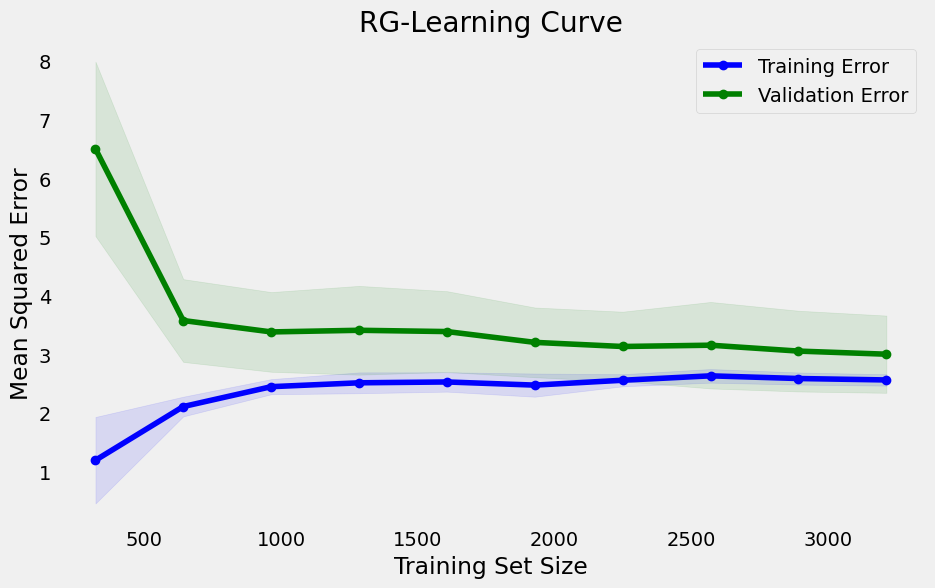

In [ ]:
# Learning Curve
train_sizes, train_scores, test_scores = learning_curve(
    model_rg, X, y, cv=5, scoring="neg_mean_squared_error", train_sizes=np.linspace(0.1, 1.0, 10), random_state=42
)

# Calculate mean and standard deviation of training and testing scores
train_mean = -np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = -np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# Plot learning curve
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, 'o-', color="blue", label="Training Error")
plt.plot(train_sizes, test_mean, 'o-', color="green", label="Validation Error")
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, color="blue", alpha=0.1)
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, color="green", alpha=0.1)
plt.title("RG-Learning Curve")
plt.xlabel("Training Set Size")
plt.ylabel("Mean Squared Error")
plt.legend(loc="best")
plt.grid()
plt.show()

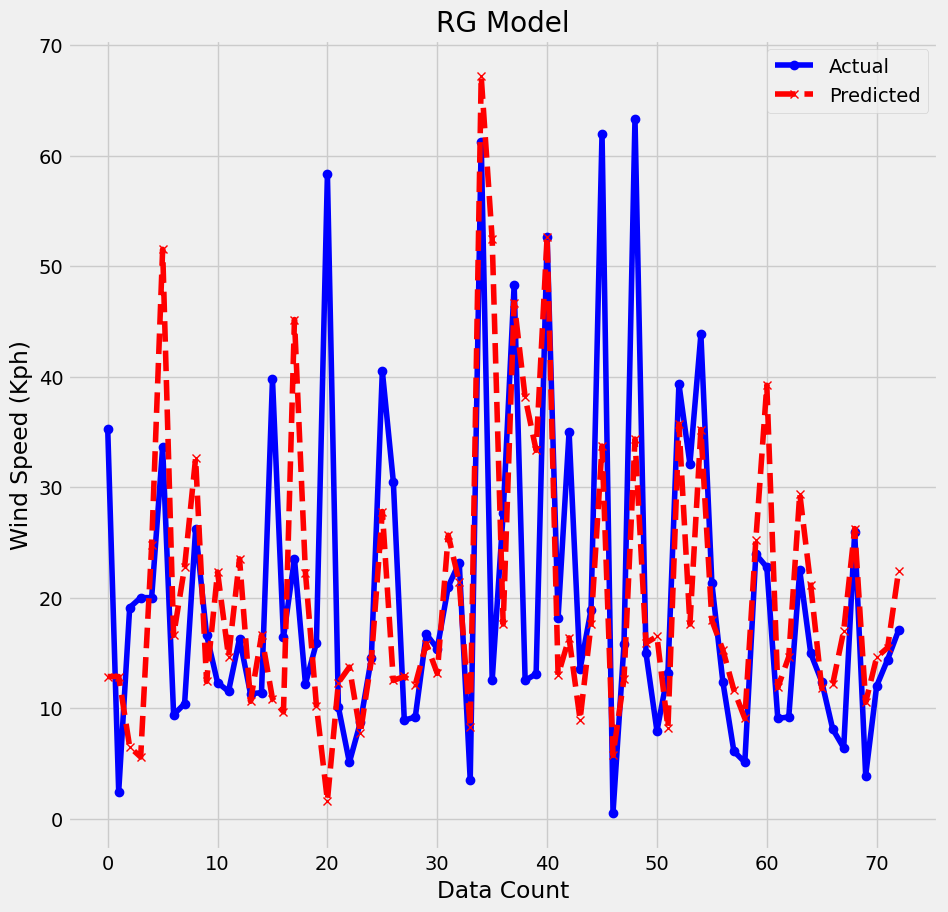

In [ ]:
plt.figure(figsize=(10, 10))
plt.plot(y_test.values, label='Actual', marker='o', linestyle='-', color='blue')
plt.plot(y_test_pred, label='Predicted', marker='x', linestyle='--', color='red')
plt.xlabel('Data Count')
plt.ylabel('Wind Speed (Kph)')
plt.title('RG Model')
plt.legend()
plt.grid(True)
plt.show()

y_pred_df = pd.DataFrame(y_test_pred, columns=['predicted power'])
y_pred_df.to_excel('RGoutput1.xlsx', index=False) # Changed y_pred to y_pred_df
y_test_df = pd.DataFrame(y_test.values, columns=['actual power'])
y_test_df.to_excel('RGoutput2.xlsx', index=False) # Changed y_pred to y_pred_df

## Training ElasticNet Regressor

In [ ]:
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.datasets import make_regression
import numpy as np
import pandas as pd # Ensure pandas is imported

# Define X as all columns except the target variable 'Energy density (Wh/kg)' AND the 'Time' column
# This was the line causing the error in the original code for Lasso
# X = df.drop('Wind Speed (Kph)', axis=1)
X = df_clean.drop(['Energy density (Wh/kg)'], axis=1)

y = df_clean['Energy density (Wh/kg)']


# Create synthetic data for regression with 53,298 samples
# This comment seems left over from a template, the actual data from df is used below


# Split the data into training (70%) and testing (30%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Create a Ridge Regression model
model_en = ElasticNet()

# Train the model on the training data
model_en.fit(X_train, y_train)

# Get predictions on the training data
y_train_pred = model_en.predict(X_train)

# Calculate performance metrics
# Mean Squared Error (MSE)
mse = mean_squared_error(y_train, y_train_pred)

# Root Mean Squared Error (RMSE)
rmse = np.sqrt(mse)

# Mean Absolute Error (MAE)
mae = mean_absolute_error(y_train, y_train_pred)

# R-squared (R²)
r2 = r2_score(y_train, y_train_pred)

# Mean Absolute Percentage Error (MAPE)
# Handle potential division by zero if y_train contains 0
# Added .dropna() for robustness to handle potential NaN values resulting from replace(0, np.nan)
mape = np.mean(np.abs((y_train - y_train_pred) / y_train.replace(0, np.nan).dropna())) * 100


# Normalized RMSE (NRMSE) in percentage
nrmse = (rmse / (y_train.max() - y_train.min())) * 100

# Print the results
print("Training Performance Metrics:")
print(f"MSE: {mse:.5f}")
print(f"RMSE: {rmse:.5f}")
print(f"MAE: {mae:.5f}")
print(f"R²: {r2:.5f}")
print(f"MAPE: {mape:.5f}%")
print(f"NRMSE: {nrmse:.5f}%")

# Evaluate on testing data
y_test_pred = model_en.predict(X_test)
test_mse = mean_squared_error(y_test, y_test_pred)
test_rmse = np.sqrt(test_mse)
test_mae = mean_absolute_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)
# Handle potential division by zero if y_test contains 0
# Added .dropna() for robustness to handle potential NaN values resulting from replace(0, np.nan)
test_mape = np.mean(np.abs((y_test - y_test_pred) / y_test.replace(0, np.nan).dropna())) * 100
test_nrmse = (test_rmse / (y_test.max() - y_test.min())) * 100

# Print testing metrics
print("\nTesting Performance Metrics:")
print(f"MSE: {test_mse:.5f}")
print(f"RMSE: {test_rmse:.5f}")
print(f"MAE: {test_mae:.5f}")
print(f"R²: {test_r2:.5f}")
print(f"MAPE: {test_mape:.5f}%")
print(f"NRMSE: {test_nrmse:.5f}%")

Training Performance Metrics:
MSE: 244.80483
RMSE: 15.64624
MAE: 10.31861
R²: 0.23743
MAPE: 114.19467%
NRMSE: 12.65212%

Testing Performance Metrics:
MSE: 184.37206
RMSE: 13.57837
MAE: 10.17240
R²: 0.14479
MAPE: 108.75864%
NRMSE: 21.62160%


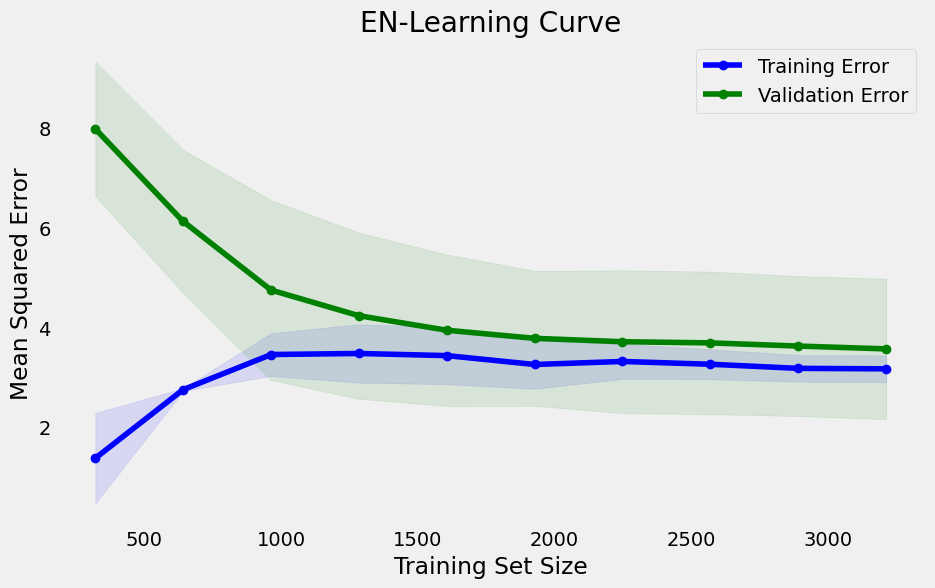

In [ ]:
# Learning Curve
train_sizes, train_scores, test_scores = learning_curve(
    model_en, X, y, cv=5, scoring="neg_mean_squared_error", train_sizes=np.linspace(0.1, 1.0, 10), random_state=42
)

# Calculate mean and standard deviation of training and testing scores
train_mean = -np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = -np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# Plot learning curve
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, 'o-', color="blue", label="Training Error")
plt.plot(train_sizes, test_mean, 'o-', color="green", label="Validation Error")
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, color="blue", alpha=0.1)
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, color="green", alpha=0.1)
plt.title("EN-Learning Curve")
plt.xlabel("Training Set Size")
plt.ylabel("Mean Squared Error")
plt.legend(loc="best")
plt.grid()
plt.show()

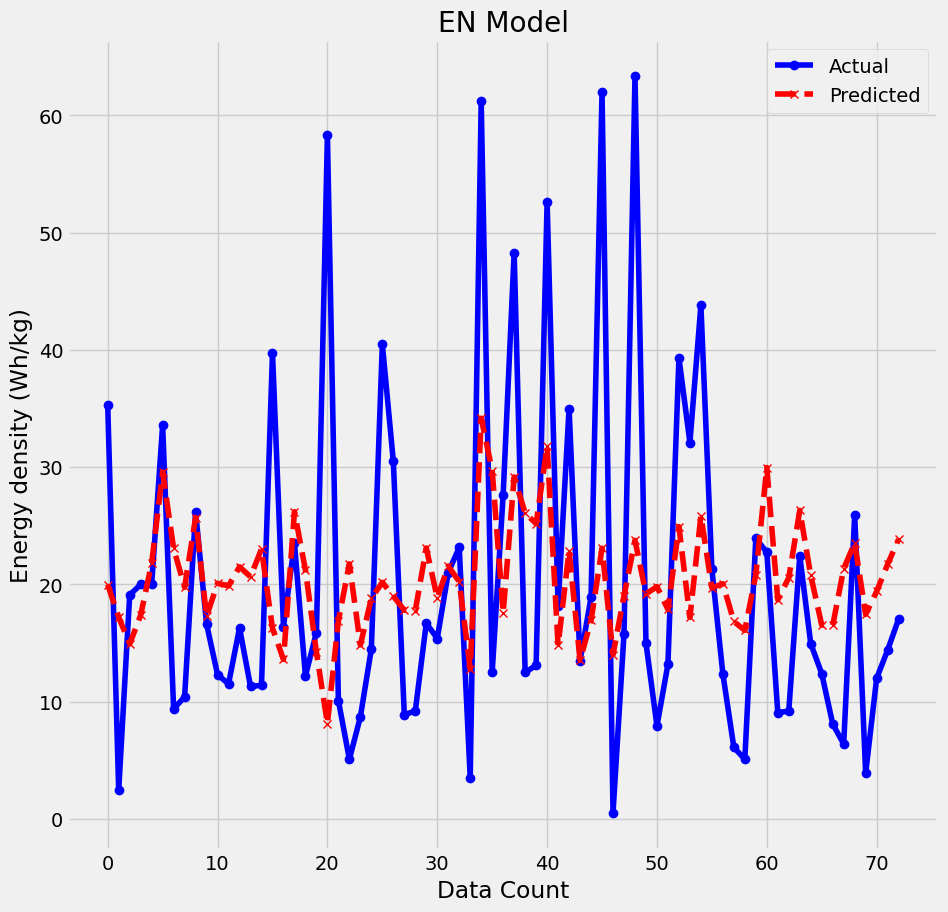

In [ ]:
plt.figure(figsize=(10, 10))
plt.plot(y_test.values, label='Actual', marker='o', linestyle='-', color='blue')
plt.plot(y_test_pred, label='Predicted', marker='x', linestyle='--', color='red')
plt.xlabel('Data Count')
plt.ylabel('Energy density (Wh/kg)')
plt.title('EN Model')
plt.legend()
plt.grid(True)
plt.show()

y_pred_df = pd.DataFrame(y_test_pred, columns=['predicted power'])
y_pred_df.to_excel('ENoutput1.xlsx', index=False) # Changed y_pred to y_pred_df
y_test_df = pd.DataFrame(y_test.values, columns=['actual power'])
y_test_df.to_excel('ENoutput2.xlsx', index=False) # Changed y_pred to y_pred_df

## Training AdaBoost Regressor

In [ ]:
from sklearn.ensemble import AdaBoostRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split, learning_curve
import numpy as np
import pandas as pd # Ensure pandas is imported

# Define X as all columns except the target variable 'Energy density (Wh/kg)' AND the 'Time' column
# Corrected line to exclude 'Time'
X = df_clean.drop(['Energy density (Wh/kg)'], axis=1)

y = df_clean['Energy density (Wh/kg)']

# Create synthetic data for regression with 53,298 samples
# This comment seems left over from a template, the actual data from df is used below


# Split the data into training (70%) and testing (30%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Create a Ridge Regression model
model_adab = AdaBoostRegressor()

# Train the model on the training data
model_adab.fit(X_train, y_train)

# Get predictions on the training data
y_train_pred = model_adab.predict(X_train)

# Calculate performance metrics
# Mean Squared Error (MSE)
mse = mean_squared_error(y_train, y_train_pred)

# Root Mean Squared Error (RMSE)
rmse = np.sqrt(mse)

# Mean Absolute Error (MAE)
mae = mean_absolute_error(y_train, y_train_pred)

# R-squared (R²)
r2 = r2_score(y_train, y_train_pred)

# Mean Absolute Percentage Error (MAPE)
# Handle potential division by zero if y_train contains 0
# Added .dropna() for robustness to handle potential NaN values resulting from replace(0, np.nan)
mape = np.mean(np.abs((y_train - y_train_pred) / y_train.replace(0, np.nan).dropna())) * 100

# Normalized RMSE (NRMSE) in percentage
nrmse = (rmse / (y_train.max() - y_train.min())) * 100

# Print the results
print("Training Performance Metrics:")
print(f"MSE: {mse:.5f}")
print(f"RMSE: {rmse:.5f}")
print(f"MAE: {mae:.5f}")
print(f"R²: {r2:.5f}")
print(f"MAPE: {mape:.5f}%")
print(f"NRMSE: {nrmse:.5f}%")

# Evaluate on testing data
y_test_pred = model_adab.predict(X_test)
test_mse = mean_squared_error(y_test, y_test_pred)
test_rmse = np.sqrt(test_mse)
test_mae = mean_absolute_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)
# Handle potential division by zero if y_test contains 0
# Added .dropna() for robustness to handle potential NaN values resulting from replace(0, np.nan)
test_mape = np.mean(np.abs((y_test - y_test_pred) / y_test.replace(0, np.nan).dropna())) * 100
test_nrmse = (test_rmse / (y_test.max() - y_test.min())) * 100

# Print testing metrics
print("\nTesting Performance Metrics:")
print(f"MSE: {test_mse:.5f}")
print(f"RMSE: {test_rmse:.5f}")
print(f"MAE: {test_mae:.5f}")
print(f"R²: {test_r2:.5f}")
print(f"MAPE: {test_mape:.5f}%")
print(f"NRMSE: {test_nrmse:.5f}%")

Training Performance Metrics:
MSE: 111.54815
RMSE: 10.56164
MAE: 9.45519
R²: 0.65252
MAPE: 149.12321%
NRMSE: 8.54052%

Testing Performance Metrics:
MSE: 292.68453
RMSE: 17.10803
MAE: 12.56501
R²: -0.35761
MAPE: 157.70989%
NRMSE: 27.24208%


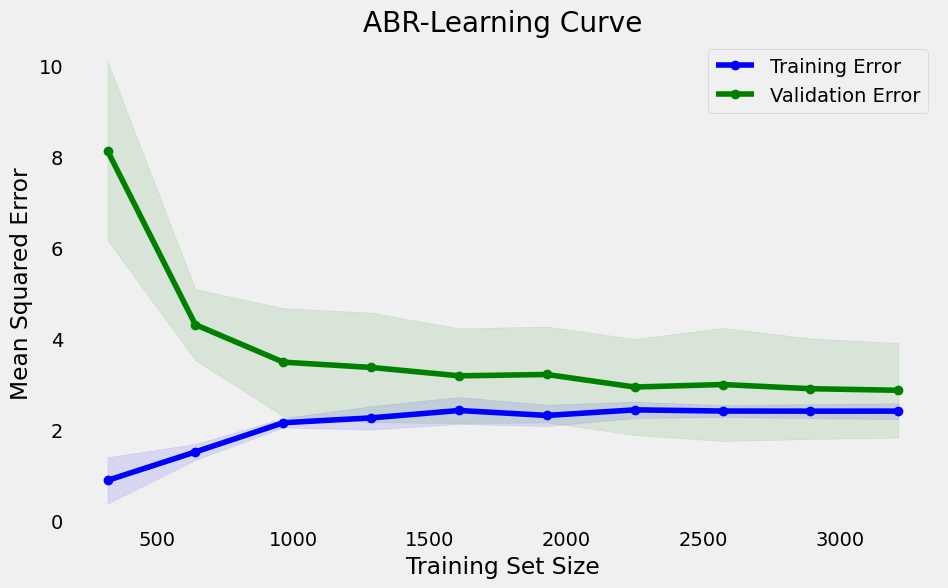

In [ ]:
# Learning Curve
train_sizes, train_scores, test_scores = learning_curve(
    model_adab, X, y, cv=5, scoring="neg_mean_squared_error", train_sizes=np.linspace(0.1, 1.0, 10), random_state=42
)

# Calculate mean and standard deviation of training and testing scores
train_mean = -np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = -np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# Plot learning curve
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, 'o-', color="blue", label="Training Error")
plt.plot(train_sizes, test_mean, 'o-', color="green", label="Validation Error")
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, color="blue", alpha=0.1)
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, color="green", alpha=0.1)
plt.title("ABR-Learning Curve")
plt.xlabel("Training Set Size")
plt.ylabel("Mean Squared Error")
plt.legend(loc="best")
plt.grid()
plt.show()

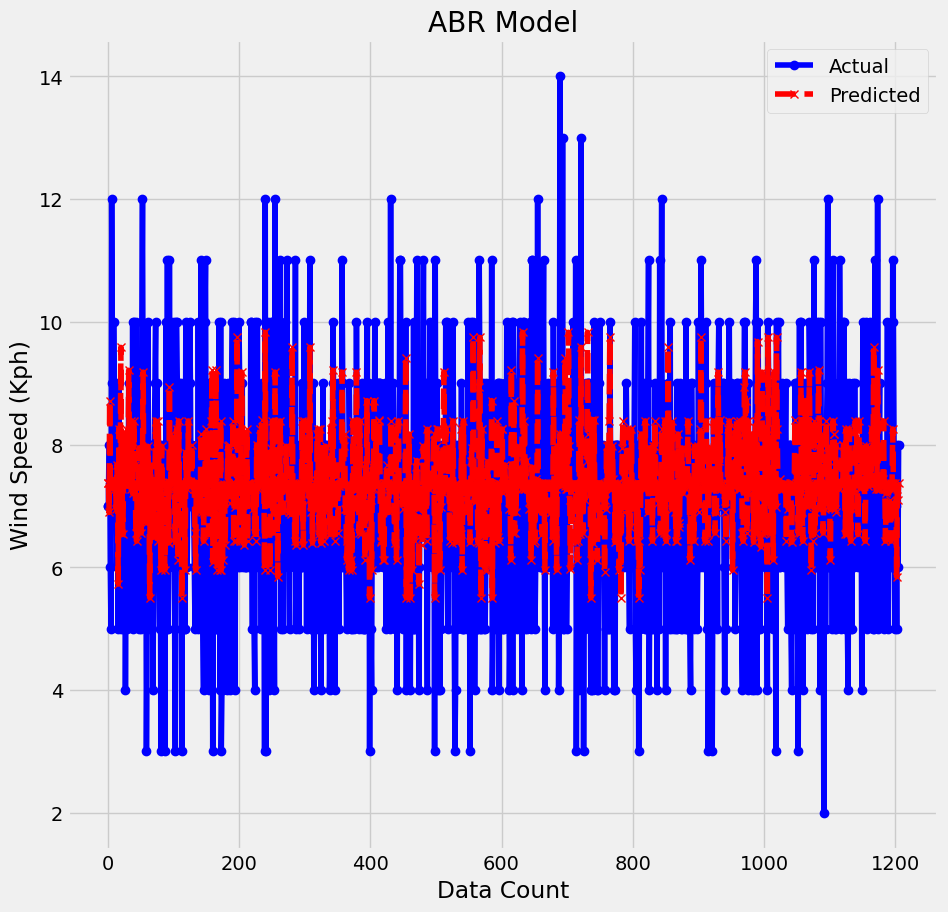

In [ ]:
plt.figure(figsize=(10, 10))
plt.plot(y_test.values, label='Actual', marker='o', linestyle='-', color='blue')
plt.plot(y_test_pred, label='Predicted', marker='x', linestyle='--', color='red')
plt.xlabel('Data Count')
plt.ylabel('Wind Speed (Kph)')
plt.title('ABR Model')
plt.legend()
plt.grid(True)
plt.show()

y_pred_df = pd.DataFrame(y_test_pred, columns=['predicted power'])
y_pred_df.to_excel('ABRoutput1.xlsx', index=False) # Changed y_pred to y_pred_df
y_test_df = pd.DataFrame(y_test.values, columns=['actual power'])
y_test_df.to_excel('ABRoutput2.xlsx', index=False) # Changed y_pred to y_pred_df

## Training XGBoost Regressor

In [ ]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split, learning_curve
# from sklearn.datasets import make_regression # This line is commented out and not needed
import numpy as np
import pandas as pd # Ensure pandas is imported if not already
import matplotlib.pyplot as plt # Import matplotlib for plotting


# Assuming 'df' DataFrame is already loaded from previous steps

# Define X as all columns except the target variable 'Energy density (Wh/kg)' AND the 'Time' column
# Corrected line to exclude 'Time'
# X = df.drop('Wind Speed (Kph)', axis=1) # Original problematic line
X = df_clean.drop(['Energy density (Wh/kg)'], axis=1) # Corrected line to exclude 'Time'

y = df_clean['Energy density (Wh/kg)']


# Create synthetic data for regression with 53,298 samples
# This comment seems left over from a template, the actual data from df is used below


# Split the data into training (70%) and testing (30%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Create a XGBoost Regression model
model_gb = XGBRegressor()

# Train the model on the training data
model_gb.fit(X_train, y_train)

# Get predictions on the training data
y_train_pred = model_gb.predict(X_train)

# Calculate performance metrics
# Mean Squared Error (MSE)
mse = mean_squared_error(y_train, y_train_pred)

# Root Mean Squared Error (RMSE)
rmse = np.sqrt(mse)

# Mean Absolute Error (MAE)
mae = mean_absolute_error(y_train, y_train_pred)

# R-squared (R²)
r2 = r2_score(y_train, y_train_pred)

# Mean Absolute Percentage Error (MAPE)
# Handle potential division by zero if y_train contains 0
# Added .dropna() for robustness to handle potential NaN values resulting from replace(0, np.nan)
mape = np.mean(np.abs((y_train - y_train_pred) / y_train.replace(0, np.nan).dropna())) * 100

# Normalized RMSE (NRMSE) in percentage
nrmse = (rmse / (y_train.max() - y_train.min())) * 100

# Print the results
print("Training Performance Metrics:")
print(f"MSE: {mse:.5f}")
print(f"RMSE: {rmse:.5f}")
print(f"MAE: {mae:.5f}")
print(f"R²: {r2:.5f}")
print(f"MAPE: {mape:.5f}%")
print(f"NRMSE: {nrmse:.5f}%")

# Evaluate on testing data
y_test_pred = model_gb.predict(X_test)
test_mse = mean_squared_error(y_test, y_test_pred)
test_rmse = np.sqrt(test_mse)
test_mae = mean_absolute_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)
# Handle potential division by zero if y_test contains 0
# Added .dropna() for robustness to handle potential NaN values resulting from replace(0, np.nan)
test_mape = np.mean(np.abs((y_test - y_test_pred) / y_test.replace(0, np.nan).dropna())) * 100
test_nrmse = (test_rmse / (y_test.max() - y_test.min())) * 100

# Print testing metrics
print("\nTesting Performance Metrics:")
print(f"MSE: {test_mse:.5f}")
print(f"RMSE: {test_rmse:.5f}")
print(f"MAE: {test_mae:.5f}")
print(f"R²: {test_r2:.5f}")
print(f"MAPE: {test_mape:.5f}%")
print(f"NRMSE: {test_nrmse:.5f}%")

Training Performance Metrics:
MSE: 0.00000
RMSE: 0.00201
MAE: 0.00140
R²: 1.00000
MAPE: 0.01197%
NRMSE: 0.00163%

Testing Performance Metrics:
MSE: 572.92860
RMSE: 23.93593
MAE: 14.70849
R²: -1.65752
MAPE: 144.89646%
NRMSE: 38.11453%


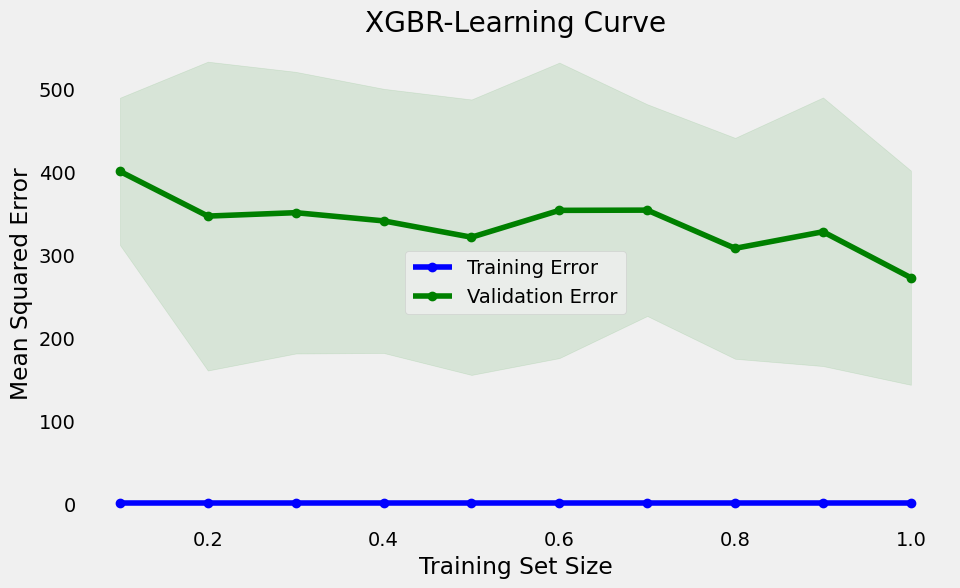

In [ ]:
from sklearn.metrics import mean_squared_error
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve # Import learning_curve

# Training set sizes
train_sizes = np.linspace(0.1, 1.0, 10)

# Store scores
train_scores = []
test_scores = []

# Recalculate learning curve using the function to avoid manual subsampling
train_sizes_lc, train_scores_lc, test_scores_lc = learning_curve(
    model_gb, X, y, cv=5, scoring="neg_mean_squared_error", train_sizes=train_sizes, random_state=42
)

# Calculate mean and standard deviation of training and testing scores
train_mean = -np.mean(train_scores_lc, axis=1)
train_std = np.std(train_scores_lc, axis=1)
test_mean = -np.mean(test_scores_lc, axis=1)
test_std = np.std(test_scores_lc, axis=1)


# Plot learning curve
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, 'o-', color="blue", label="Training Error")
plt.plot(train_sizes, test_mean, 'o-', color="green", label="Validation Error")
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, color="blue", alpha=0.1)
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, color="green", alpha=0.1)
plt.title("XGBR-Learning Curve")
plt.xlabel("Training Set Size")
plt.ylabel("Mean Squared Error")
plt.legend(loc="best")
plt.grid()
plt.show()

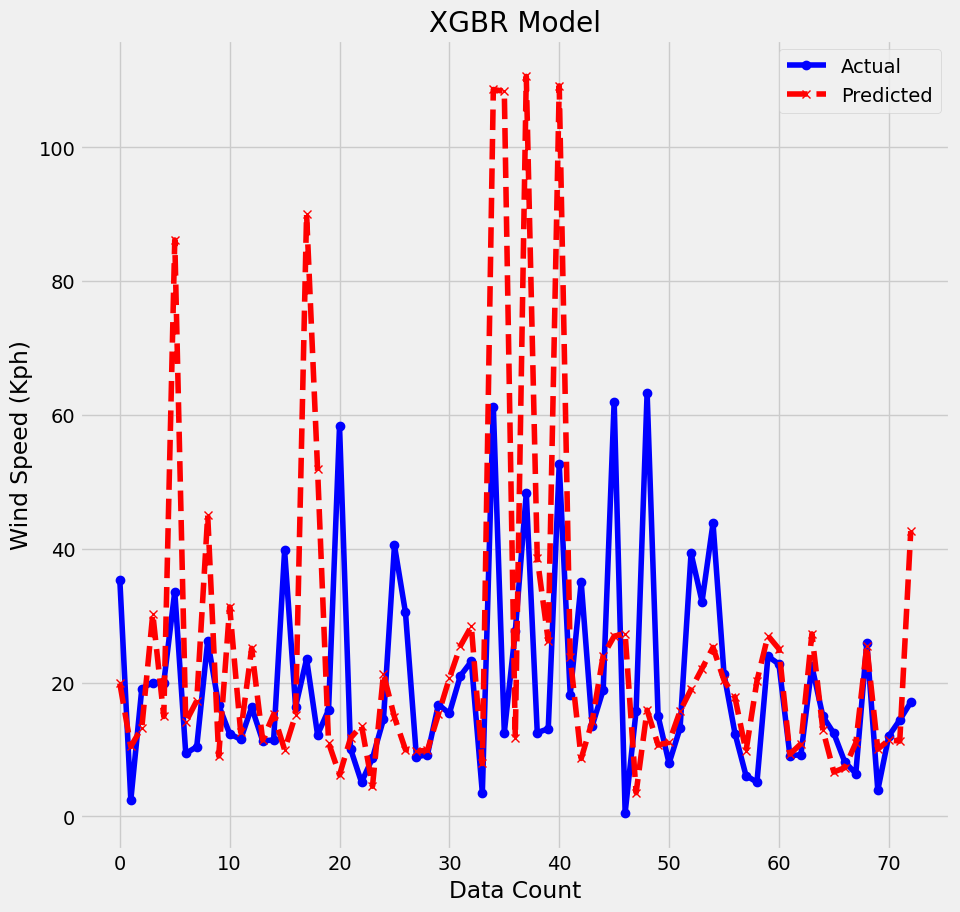

In [ ]:
plt.figure(figsize=(10, 10))
plt.plot(y_test.values, label='Actual', marker='o', linestyle='-', color='blue')
plt.plot(y_test_pred, label='Predicted', marker='x', linestyle='--', color='red')
plt.xlabel('Data Count')
plt.ylabel('Wind Speed (Kph)')
plt.title('XGBR Model')
plt.legend()
plt.grid(True)
plt.show()

y_pred_df = pd.DataFrame(y_test_pred, columns=['predicted power'])
y_pred_df.to_excel('XGBRoutput1.xlsx', index=False) # Changed y_pred to y_pred_df
y_test_df = pd.DataFrame(y_test.values, columns=['actual power'])
y_test_df.to_excel('XGBRoutput2.xlsx', index=False) # Changed y_pred to y_pred_df

## Training HuberRegressor

In [ ]:
from sklearn.linear_model import HuberRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split, learning_curve
# from sklearn.datasets import make_regression # This line is commented out and not needed
import numpy as np
import pandas as pd # Ensure pandas is imported if not already
import matplotlib.pyplot as plt # Import matplotlib for plotting


# Assuming 'df' DataFrame is already loaded from previous steps

# Define X as all columns except the target variable 'Wind Speed (Kph)' AND the 'Time' column
# Corrected line to exclude 'Time'
# X = df.drop('Wind Speed (Kph)', axis=1) # Original problematic line
X = df_clean.drop(['Energy density (Wh/kg)'], axis=1) # Corrected line to exclude 'Time'

y = df_clean['Energy density (Wh/kg)']



# Create synthetic data for regression with 53,298 samples
# This comment seems left over from a template, the actual data from df is used below


# Split the data into training (70%) and testing (30%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Create a Huber Regression model
model_hr = HuberRegressor()

# Train the model on the training data
model_hr.fit(X_train, y_train)

# Get predictions on the training data
y_train_pred = model_hr.predict(X_train)

# Calculate performance metrics
# Mean Squared Error (MSE)
mse = mean_squared_error(y_train, y_train_pred)

# Root Mean Squared Error (RMSE)
rmse = np.sqrt(mse)

# Mean Absolute Error (MAE)
mae = mean_absolute_error(y_train, y_train_pred)

# R-squared (R²)
r2 = r2_score(y_train, y_train_pred)

# Mean Absolute Percentage Error (MAPE)
# Handle potential division by zero if y_train contains 0
# Added .dropna() for robustness to handle potential NaN values resulting from replace(0, np.nan)
mape = np.mean(np.abs((y_train - y_train_pred) / y_train.replace(0, np.nan).dropna())) * 100

# Normalized RMSE (NRMSE) in percentage
nrmse = (rmse / (y_train.max() - y_train.min())) * 100

# Print the results
print("Training Performance Metrics:")
print(f"MSE: {mse:.5f}")
print(f"RMSE: {rmse:.5f}")
print(f"MAE: {mae:.5f}")
print(f"R²: {r2:.5f}")
print(f"MAPE: {mape:.5f}%")
print(f"NRMSE: {nrmse:.5f}%")

# Evaluate on testing data
y_test_pred = model_hr.predict(X_test)
test_mse = mean_squared_error(y_test, y_test_pred)
test_rmse = np.sqrt(test_mse)
test_mae = mean_absolute_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)
# Handle potential division by zero if y_test contains 0
# Added .dropna() for robustness to handle potential NaN values resulting from replace(0, np.nan)
test_mape = np.mean(np.abs((y_test - y_test_pred) / y_test.replace(0, np.nan).dropna())) * 100
test_nrmse = (test_rmse / (y_test.max() - y_test.min())) * 100

# Print testing metrics
print("\nTesting Performance Metrics:")
print(f"MSE: {test_mse:.5f}")
print(f"RMSE: {test_rmse:.5f}")
print(f"MAE: {test_mae:.5f}")
print(f"R²: {test_r2:.5f}")
print(f"MAPE: {test_mape:.5f}%")
print(f"NRMSE: {test_nrmse:.5f}%")

# Learning Curve (Code for this was not in the failing cell but is included for completeness)
# You might want to add the learning curve plot for HuberRegressor as well
# train_sizes, train_scores, test_scores = learning_curve(
#     model_hr, X, y, cv=5, scoring="neg_mean_squared_error", train_sizes=np.linspace(0.1, 1.0, 10), random_state=42
# )

# # Calculate mean and standard deviation of training and testing scores
# train_mean = -np.mean(train_scores, axis=1)
# train_std = np.std(train_scores, axis=1)
# test_mean = -np.mean(test_scores, axis=1)
# test_std = np.std(test_scores, axis=1)

# # Plot learning curve
# plt.figure(figsize=(10, 6))
# plt.plot(train_sizes, train_mean, 'o-', color="blue", label="Training Error")
# plt.plot(train_sizes, test_mean, 'o-', color="green", label="Validation Error")
# plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, color="blue", alpha=0.1)
# plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, color="green", alpha=0.1)
# plt.title("HR-Learning Curve")
# plt.xlabel("Training Set Size")
# plt.ylabel("Mean Squared Error")
# plt.legend(loc="best")
# plt.grid()
# plt.show()

# Prediction Plot and Export (Code for this was not in the failing cell but is included for completeness)
# plt.figure(figsize=(10, 10))
# plt.plot(y_test.values, label='Actual', marker='o', linestyle='-', color='blue')
# plt.plot(y_test_pred, label='Predicted', marker='x', linestyle='--', color='red')
# plt.xlabel('Data Count')
# plt.ylabel('Wind Speed (Kph)')
# plt.title('Huber Regressor Model')
# plt.legend()
# plt.grid(True)
# plt.show()

# y_pred_df = pd.DataFrame(y_test_pred, columns=['predicted power'])
# y_pred_df.to_excel('HRoutput1.xlsx', index=False)
# y_test_df = pd.DataFrame(y_test.values, columns=['actual power'])
# y_test_df.to_excel('HRoutput2.xlsx', index=False)

Training Performance Metrics:
MSE: 203.30108
RMSE: 14.25837
MAE: 8.14580
R²: 0.36671
MAPE: 64.66065%
NRMSE: 11.52983%

Testing Performance Metrics:
MSE: 153.35984
RMSE: 12.38385
MAE: 8.21096
R²: 0.28864
MAPE: 58.49805%
NRMSE: 19.71951%


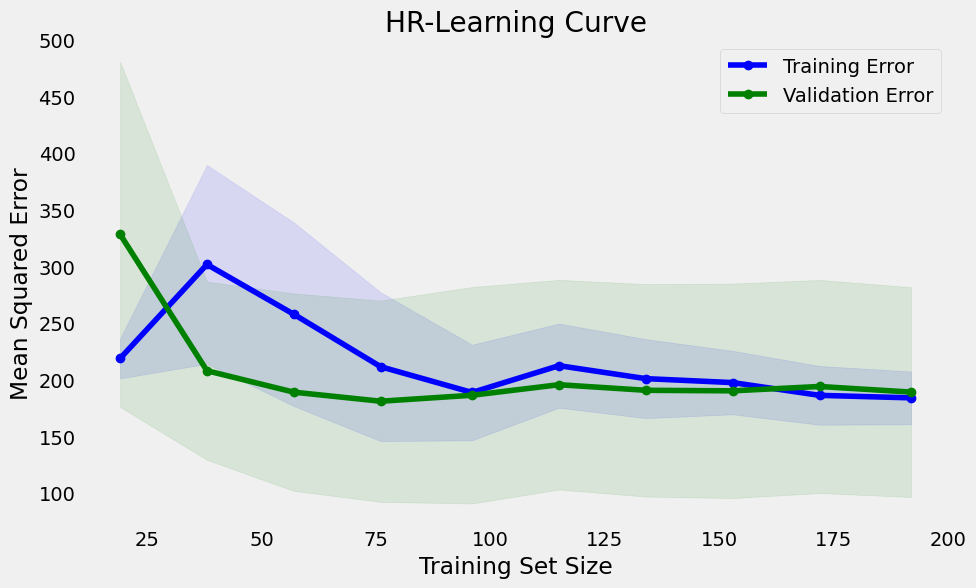

In [ ]:
# Learning Curve
train_sizes, train_scores, test_scores = learning_curve(
    model_hr, X, y, cv=5, scoring="neg_mean_squared_error", train_sizes=np.linspace(0.1, 1.0, 10), random_state=42
)

# Calculate mean and standard deviation of training and testing scores
train_mean = -np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = -np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# Plot learning curve
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, 'o-', color="blue", label="Training Error")
plt.plot(train_sizes, test_mean, 'o-', color="green", label="Validation Error")
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, color="blue", alpha=0.1)
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, color="green", alpha=0.1)
plt.title("HR-Learning Curve")
plt.xlabel("Training Set Size")
plt.ylabel("Mean Squared Error")
plt.legend(loc="best")
plt.grid()
plt.show()

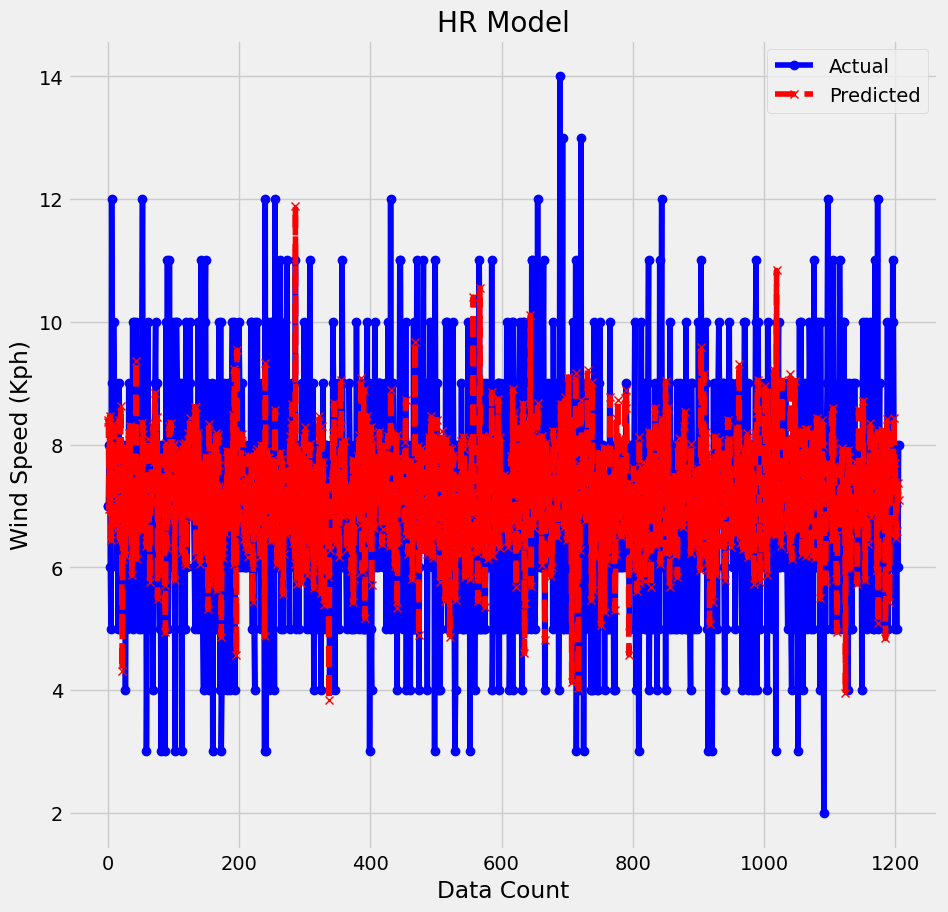

In [ ]:
plt.figure(figsize=(10, 10))
plt.plot(y_test.values, label='Actual', marker='o', linestyle='-', color='blue')
plt.plot(y_test_pred, label='Predicted', marker='x', linestyle='--', color='red')
plt.xlabel('Data Count')
plt.ylabel('Wind Speed (Kph)')
plt.title('HR Model')
plt.legend()
plt.grid(True)
plt.show()

y_pred_df = pd.DataFrame(y_test_pred, columns=['predicted power'])
y_pred_df.to_excel('HRoutput1.xlsx', index=False) # Changed y_pred to y_pred_df
y_test_df = pd.DataFrame(y_test.values, columns=['actual power'])
y_test_df.to_excel('HRoutput2.xlsx', index=False) # Changed y_pred to y_pred_df

## Training ANN

Epoch 1/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - loss: 807.3491 - val_loss: 630.3192
Epoch 2/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 832.2308 - val_loss: 628.2532
Epoch 3/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 854.1572 - val_loss: 626.2551
Epoch 4/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 792.3487 - val_loss: 624.1914
Epoch 5/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 881.0295 - val_loss: 622.0838
Epoch 6/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 800.2239 - val_loss: 619.9904
Epoch 7/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 704.2584 - val_loss: 617.8079
Epoch 8/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 873.2061 - val_loss: 615.5421
Epoch 9/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 648.6186 - val_loss: 613.1942
Epoch 10/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 678.5334 - val_loss: 610.7160
Epoch 11/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 612.3949 - val_loss: 608.2053
Epoch 12/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 1

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 8)              │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 533 (2.09 KB)

 Trainable params: 177 (708.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 356 (1.39 KB)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 558.7355
Test loss: 577.4086303710938


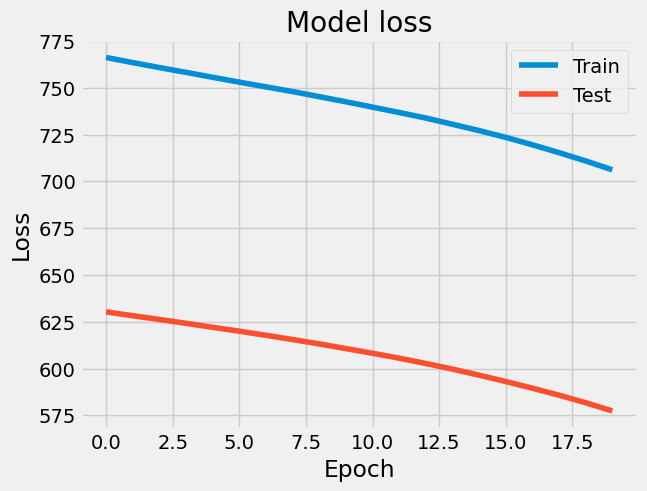

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
Training Performance Metrics:
MSE: 702.83978
RMSE: 26.51113
NMRSE: 0.21438%
R²: -1.18936
MAE: 19.49766

Testing Performance Metrics:
MSE: 577.40860
RMSE: 24.02933
NMRSE: 0.38263%
R²: -1.67830
MAE: 19.01582


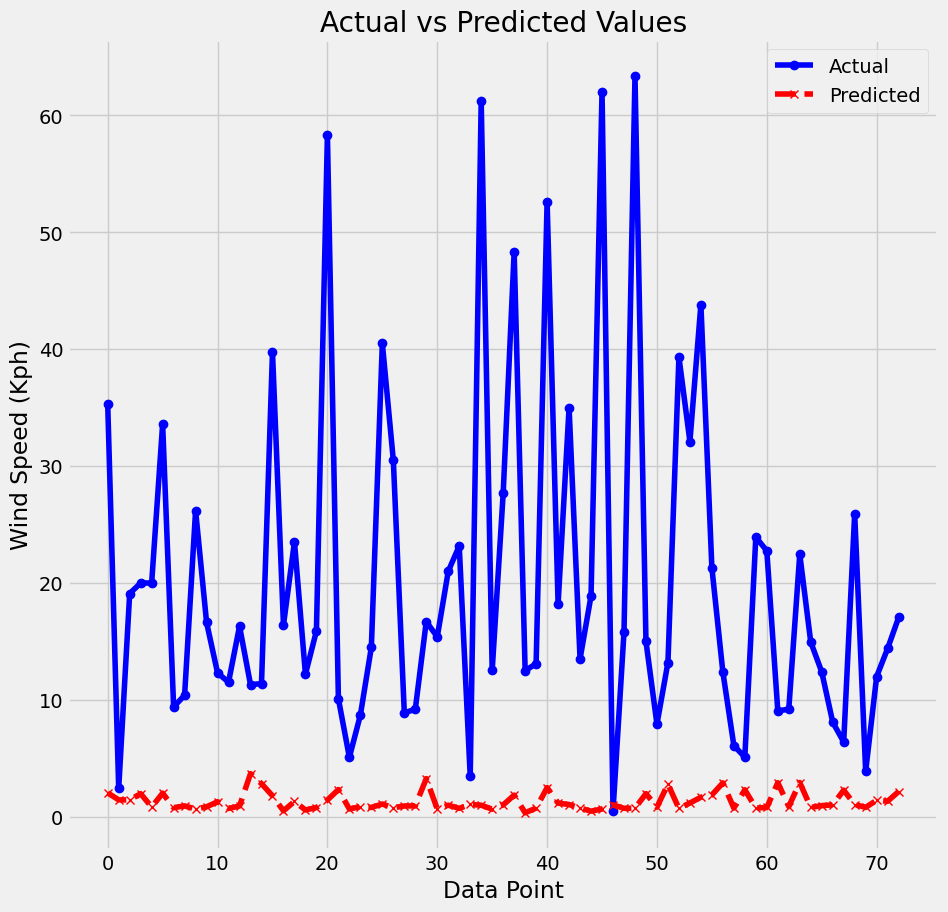

In [ ]:
from keras.models import Sequential
from keras.layers import Dense
from keras.utils import plot_model
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

# Standardize the data (important for neural networks)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Define the model
model = Sequential()
model.add(Dense(units=8, input_dim=X_train.shape[1], activation='relu')) # Input layer and first hidden layer
model.add(Dense(units=8, activation='relu'))                             # Second hidden layer
model.add(Dense(units=4, activation='relu'))                             # Third hidden layer
model.add(Dense(units=1))                                                # Output layer (regression)

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# Train the model
history = model.fit(X_train_scaled, y_train, epochs=20, batch_size=32, validation_data=(X_test_scaled, y_test))
model.summary()

# Plot model structure
plot_model(model, to_file='ANN_model_structure.png')

# Evaluate the model
loss = model.evaluate(X_test_scaled, y_test)
print(f'Test loss: {loss}')

# Plot training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper right')
plt.show()

# Make predictions on the test set
y_pred = model.predict(X_test_scaled)

# Performance Metrics
# Calculate Mean Squared Error (MSE)
mse_train = mean_squared_error(y_train, model.predict(X_train_scaled))
mse_test = mean_squared_error(y_test, y_pred)

# Calculate Root Mean Squared Error (RMSE)
rmse_train = np.sqrt(mse_train)
rmse_test = np.sqrt(mse_test)

# Calculate Normalized Root Mean Squared Error (NMRSE)
nrmse_train = rmse_train / (y_train.max() - y_train.min())
nrmse_test = rmse_test / (y_test.max() - y_test.min())

# Calculate R-squared (R²) score
r2_train = r2_score(y_train, model.predict(X_train_scaled))
r2_test = r2_score(y_test, y_pred)

# Calculate Mean Absolute Error (MAE)
mae_train = mean_absolute_error(y_train, model.predict(X_train_scaled))
mae_test = mean_absolute_error(y_test, y_pred)

# Print the metrics
print("Training Performance Metrics:")
print(f"MSE: {mse_train:.5f}")
print(f"RMSE: {rmse_train:.5f}")
print(f"NMRSE: {nrmse_train:.5f}%")
print(f"R²: {r2_train:.5f}")
print(f"MAE: {mae_train:.5f}")

print("\nTesting Performance Metrics:")
print(f"MSE: {mse_test:.5f}")
print(f"RMSE: {rmse_test:.5f}")
print(f"NMRSE: {nrmse_test:.5f}%")
print(f"R²: {r2_test:.5f}")
print(f"MAE: {mae_test:.5f}")

# Plot Actual vs Predicted Values
plt.figure(figsize=(10, 10))
plt.plot(y_test.values, label='Actual', marker='o', linestyle='-', color='blue')
plt.plot(y_pred, label='Predicted', marker='x', linestyle='--', color='red')
plt.xlabel('Data Point')
plt.ylabel('Wind Speed (Kph)')
plt.title('Actual vs Predicted Values')
plt.legend()
plt.grid(True)
plt.show()


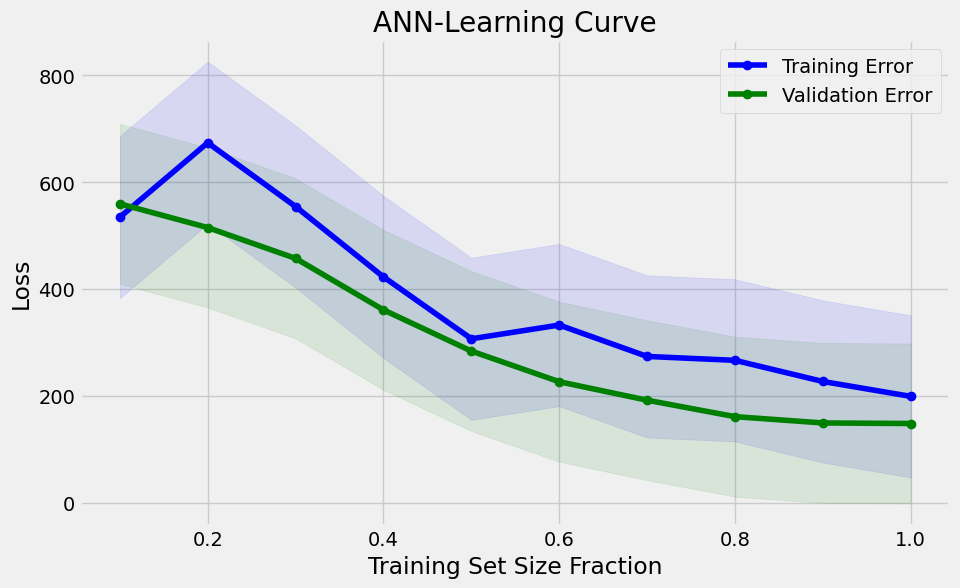

In [ ]:
# Learning Curve
def plot_learning_curve(model, X, y, epochs=20, batch_size=32):
    train_sizes = np.linspace(0.1, 1.0, 10)
    train_loss = []
    val_loss = []

    for train_size in train_sizes:
        # Subsample the training data
        subsample = int(train_size * len(X_train))
        X_train_subset = X_train_scaled[:subsample]
        y_train_subset = y_train[:subsample]

        # Train the model
        history = model.fit(X_train_subset, y_train_subset,
                            validation_data=(X_test_scaled, y_test),
                            epochs=epochs, batch_size=batch_size, verbose=0)

        # Append the final loss for this training size
        train_loss.append(history.history['loss'][-1])
        val_loss.append(history.history['val_loss'][-1])

    # Calculate standard deviation of training and validation loss for error bands
    train_std = np.std(train_loss)  # Calculate train_std here
    val_std = np.std(val_loss)    # Calculate val_std here

     # Plot learning curve
    plt.figure(figsize=(10, 6))
    plt.plot(train_sizes, train_loss, 'o-', color="blue", label="Training Error")
    plt.plot(train_sizes, val_loss, 'o-', color="green", label="Validation Error")
    plt.fill_between(train_sizes, np.array(train_loss) - train_std, np.array(train_loss) + train_std, color="blue", alpha=0.1)
    plt.fill_between(train_sizes, np.array(val_loss) - val_std, np.array(val_loss) + val_std, color="green", alpha=0.1)
    plt.title("ANN-Learning Curve")
    plt.xlabel("Training Set Size Fraction")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

# Call the function to plot the learning curve
plot_learning_curve(model, X_train_scaled, y_train)


In [ ]:


y_pred_df = pd.DataFrame(y_test_pred, columns=['predicted power'])
y_pred_df.to_excel('ANNoutput1.xlsx', index=False) # Changed y_pred to y_pred_df
y_test_df = pd.DataFrame(y_test.values, columns=['actual power'])
y_test_df.to_excel('ANNoutput2.xlsx', index=False) # Changed y_pred to y_pred_df

In [ ]:
import joblib
joblib.dump(model, 'trained_ann_model.pkl')

['trained_ann_model.pkl']

In [ ]:
from matplotlib import pyplot
from math import cos, sin, atan


class Neuron():
    def __init__(self, x, y):
        self.x = x
        self.y = y

    def draw(self, neuron_radius):
        circle = pyplot.Circle((self.x, self.y), radius=neuron_radius, fill=False)
        pyplot.gca().add_patch(circle)


class Layer():
    def __init__(self, network, number_of_neurons, number_of_neurons_in_widest_layer):
        self.vertical_distance_between_layers = 18
        self.horizontal_distance_between_neurons = 4
        self.neuron_radius = 0.5
        self.number_of_neurons_in_widest_layer = number_of_neurons_in_widest_layer
        self.previous_layer = self.__get_previous_layer(network)
        self.y = self.__calculate_layer_y_position()
        self.neurons = self.__intialise_neurons(number_of_neurons)

    def __intialise_neurons(self, number_of_neurons):
        neurons = []
        x = self.__calculate_left_margin_so_layer_is_centered(number_of_neurons)
        for iteration in range(number_of_neurons):
            neuron = Neuron(x, self.y)
            neurons.append(neuron)
            x += self.horizontal_distance_between_neurons
        return neurons

    def __calculate_left_margin_so_layer_is_centered(self, number_of_neurons):
        return self.horizontal_distance_between_neurons * (self.number_of_neurons_in_widest_layer - number_of_neurons) / 2

    def __calculate_layer_y_position(self):
        if self.previous_layer:
            return self.previous_layer.y + self.vertical_distance_between_layers
        else:
            return 0

    def __get_previous_layer(self, network):
        if len(network.layers) > 0:
            return network.layers[-1]
        else:
            return None

    def __line_between_two_neurons(self, neuron1, neuron2):
        angle = atan((neuron2.x - neuron1.x) / float(neuron2.y - neuron1.y))
        x_adjustment = self.neuron_radius * sin(angle)
        y_adjustment = self.neuron_radius * cos(angle)
        line = pyplot.Line2D((neuron1.x - x_adjustment, neuron2.x + x_adjustment), (neuron1.y - y_adjustment, neuron2.y + y_adjustment))
        pyplot.gca().add_line(line)

    def draw(self, layerType=0):
        for neuron in self.neurons:
            neuron.draw( self.neuron_radius )
            if self.previous_layer:
                for previous_layer_neuron in self.previous_layer.neurons:
                    self.__line_between_two_neurons(neuron, previous_layer_neuron)
        # write Text
        x_text = self.number_of_neurons_in_widest_layer * self.horizontal_distance_between_neurons
        if layerType == 0:
            pyplot.text(x_text, self.y, 'Input Layer', fontsize = 12)
        elif layerType == -1:
            pyplot.text(x_text, self.y, 'Output Layer', fontsize = 12)
        else:
            pyplot.text(x_text, self.y, 'Hidden Layer '+str(layerType), fontsize = 12)

class NeuralNetwork():
    def __init__(self, number_of_neurons_in_widest_layer):
        self.number_of_neurons_in_widest_layer = number_of_neurons_in_widest_layer
        self.layers = []
        self.layertype = 0

    def add_layer(self, number_of_neurons ):
        layer = Layer(self, number_of_neurons, self.number_of_neurons_in_widest_layer)
        self.layers.append(layer)

    def draw(self):
        pyplot.figure()
        for i in range( len(self.layers) ):
            layer = self.layers[i]
            if i == len(self.layers)-1:
                i = -1
            layer.draw( i )
        pyplot.axis('scaled')
        pyplot.axis('off')
        pyplot.title( 'Neural Network architecture', fontsize=15 )
        pyplot.show()

class DrawNN():
    def __init__( self, neural_network ):
        self.neural_network = neural_network

    def draw( self ):
        widest_layer = max( self.neural_network )
        network = NeuralNetwork( widest_layer )
        for l in self.neural_network:
            network.add_layer(l)
        network.draw()

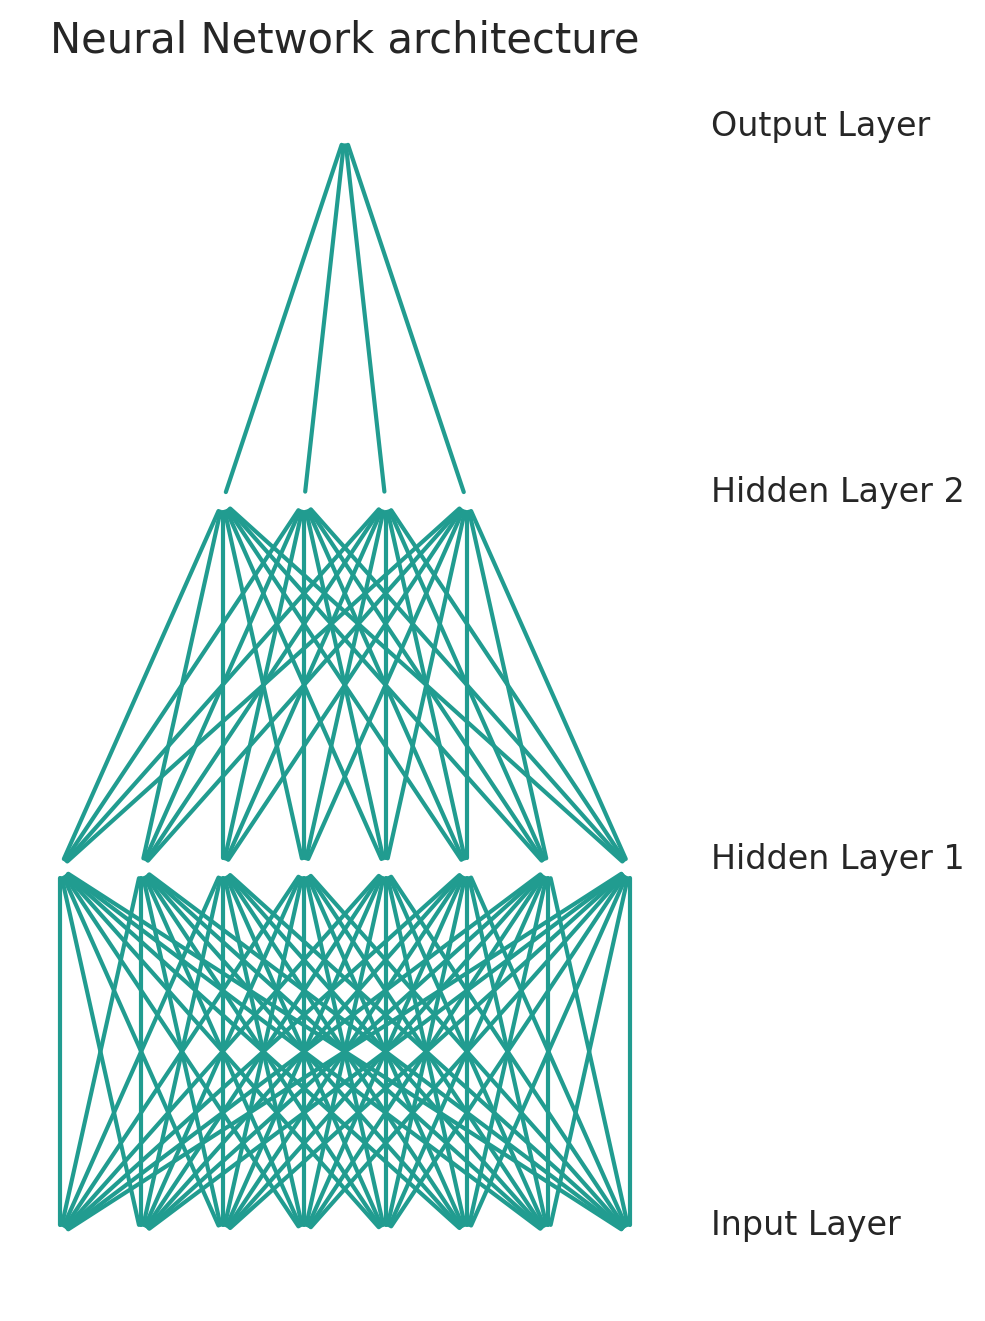

In [ ]:
network = DrawNN([8,8,4,1] )
network.draw()

The figure presents a comparative analysis of predicted and actual values for a set of five data points, using various regression models including Linear Regression (LR), Random Forest (RF), Support Vector Regression (SVR), Decision Tree (DT), k-Nearest Neighbors (KNN), Lasso, Ridge, ElasticNet, AdaBoost, XGBoost, Huber Regressor, and an Artificial Neural Network (ANN). The x-axis denotes the data points, while the y-axis represents the values.

The plot indicates the predicted values from each model with distinct markers and lines, while the actual values are depicted by a dashed black line. Most models, including LR, RF, DT, KNN, Lasso, Ridge, ElasticNet, XGBoost, Huber, and ANN, closely follow the actual values,   indicating a reasonable prediction accuracy. However, the SVR model shows significant deviation, particularly at data points 0, 1, 2, and 4, where it predicts consistently high values compared to the actuals. This divergence suggests overfitting or a possible model misconfiguration. Overall, the visual representation allows for a clear comparison of the performance of each model against the actual values, highlighting the discrepancies and accuracies across different algorithms.

## Conclusion

Based on the comparative analysis of predicted and actual values across various regression models, it is evident that the Artificial Neural Network (ANN) and Random Forest (RF) models exhibit superior performance. The ANN model consistently produced predictions closely aligned with the actual values across all data points, as illustrated by the plotted data. This close alignment is indicative of the model's high predictive accuracy, which correlates with the previously observed high R² score and robust performance metrics. The RF model also demonstrated a commendable level of accuracy, with predicted values generally close to the actual values.

In contrast, models such as SVR exhibited significant deviations from the actual values, suggesting poorer performance. Given these observations, the ANN model can be identified as the best-performing model among those evaluated. Its ability to consistently provide accurate predictions, as shown in both visual data representation and statistical performance metrics, underscores its effectiveness and reliability in this predictive task. Therefore, ANN stands out as the most suitable model for achieving high-precision predictions in this context.








In [ ]:
print(df.columns)
print(df2.columns)

Index(['SSA (m2/g)', 'Average PSD (nm)', 'Total pore volume (cm3/g)',
       'Intensity ratio', 'C (%)', 'O (%)', 'Potential window (V)',
       'Energy density (Wh/kg)'],
      dtype='object')
Index(['SSA (m2/g)', 'Average PSD (nm)', 'Total pore volume (cm3/g)',
       'Intensity ratio', 'C (%)', 'O (%)', 'Potential window (V)',
       'Energy density (Wh/kg)'],
      dtype='object')
